# EDA: wypowiedzi sejmowe a konsensus naukowy

**Cel.** Rozpoznać materiał przed właściwą analizą zgodności / sprzeczności wypowiedzi posłów z konsensusem naukowym.
Odpowiadamy na trzy pytania:

1. **Tematy** — czy da się zawęzić projekt do konkretnych obszarów (szczepienia, COVID, klimat, energetyka jądrowa, GMO, 5G, smog, in vitro) i ile materiału każdy daje?
2. **Czas** — jak liczba wypowiedzi na te tematy zmienia się w czasie (trend, piki, różnice między kadencjami)?
3. **Partie** — które kluby mówią o tych tematach najwięcej i gdzie pojawiają się odwołania do nauki lub zwroty ją podważające?

**Dane.** Stenogramy posiedzeń plenarnych Sejmu z API `api.sejm.gov.pl`, kadencje **VIII (2015–2019), IX (2019–2023), X (2023–)**,
pobrane skryptem `src/fetch_sejm.py`. Klub przypisany jest **na dzień wypowiedzi** (z list głosowań), a nie wg stanu obecnego.

**Metoda tematyczna.** Słowniki wyrażeń regularnych z `src/topics.py` (rdzenie słów + odmiana). To filtr *wysokiej precyzji, niepełnej czułości*
— służy do oszacowania skali i rozkładów, nie do ostatecznej klasyfikacji.

> Spis treści: 0. Przygotowanie · 1. Przegląd korpusu · 2. Czyszczenie · 3. Kluby → bloki · 4. Tematy · 5. Trend w czasie · 6. Partie · 7. Nauka i sceptycyzm · 8. Komisje sejmowe · 9. Wnioski

In [1]:
import sys, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import topics as T

FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
PROC = ROOT / "data" / "processed"; PROC.mkdir(parents=True, exist_ok=True)
TERMS = [8, 9, 10]
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### Styl wykresów
Jedna spójna paleta: **kolor zawsze oznacza ten sam blok partyjny** (kolejność barw zwalidowana pod kątem daltonizmu dla sąsiadujących par).
Natężenie (heatmapy) — jedna barwa od jasnej do ciemnej. Tematy rozróżniamy pozycją (osobne panele / etykiety), nie kolorem.

In [2]:
INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
ACCENT = "#2a78d6"
BLOK_KOLOR = {
    "PiS": "#2a78d6", "KO": "#eb6834", "Kukiz'15": "#1baf7a", "Polska 2050": "#eda100",
    "Lewica": "#e87ba4", "PSL": "#008300", "Konfederacja": "#4a3aa7", "Inne / niez.": "#b5b3ac",
}
BLOKI = list(BLOK_KOLOR)
SEQ = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 22,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "lines.linewidth": 2,
})

def save(fig, name):
    fig.savefig(FIG / f"{name}.png")

def subtitle(ax, text):
    ax.annotate(text, xy=(0, 1), xycoords="axes fraction", xytext=(0, 2), textcoords="offset points",
                fontsize=9, color=INK2, va="bottom")

## 0. Wczytanie danych

In [3]:
df = pd.concat([pd.read_parquet(ROOT / f"data/interim/wypowiedzi_term{t}.parquet") for t in TERMS], ignore_index=True)
df["data"] = pd.to_datetime(df["data"])
df["miesiac"] = df["data"].dt.to_period("M").dt.to_timestamp()
df["rok"] = df["data"].dt.year
print(f"{len(df):,} wypowiedzi, {df['liczba_slow'].sum():,} słów, {df['data'].min():%Y-%m-%d} – {df['data'].max():%Y-%m-%d}")
df.head(3)

130,515 wypowiedzi, 46,186,180 słów, 2015-11-12 – 2026-09-18


,wypowiedz_id,kadencja,posiedzenie,data,num,start,koniec,mowca,member_id,klub,klub_dzis,funkcja,rapporteur,secretary,niewygloszona,tekst,liczba_slow,miesiac,rok
0,8_1_2015-11-12_0,8,1,2015-11-12,0,2015-11-12T13:04:00,2015-11-12T19:51:00,Marszałek,0,NaN,NaN,,False,False,False,"8. kadencja, 1. posiedzenie, 1. dzień - Marszałek\n8. kadencja, 1. posiedzenie, 1. dzień (12-11-2015)\n(Początek posiedzenia o godz. 13 min 04)\n(Na posiedzeniu przewodniczą marszałek senior Korne...",3231,2015-11-01,2015
1,8_1_2015-11-12_1,8,1,2015-11-12,1,2015-11-12T13:09:30,2015-11-12T13:23:40,Andrzej Duda,0,NaN,NaN,Prezydent Rzeczypospolitej Polskiej,False,False,False,"8. kadencja, 1. posiedzenie, 1. dzień - Prezydent Rzeczypospolitej Polskiej Andrzej Duda\n8. kadencja, 1. posiedzenie, 1. dzień (12-11-2015)\nPrezydent Rzeczypospolitej Polskiej Andrzej Duda:\nDro...",1494,2015-11-01,2015
2,8_1_2015-11-12_2,8,1,2015-11-12,2,NaN,NaN,Paweł Szefernaker,375,PiS,PiS,Sekretarz Poseł,False,True,False,"8. kadencja, 1. posiedzenie, 1. dzień - Sekretarz Poseł Paweł Szefernaker\n8. kadencja, 1. posiedzenie, 1. dzień (12-11-2015)\nSekretarz Poseł Paweł Szefernaker:\n(Sekretarz poseł odczytuje nazwis...",98,2015-11-01,2015


### Czyszczenie tekstu
**Czyszczenie tekstu.** Surowy tekst wypowiedzi zawiera elementy, które nie są słowami mówcy, a zaburzałyby filtr słownikowy:
* **nagłówek stenogramu** — w pierwszej wypowiedzi punktu obrad zawiera *tytuł punktu porządku dziennego*
  (np. „Informacja Ministra Zdrowia w sprawie Narodowego Programu Szczepień”) — dałby trafienia tematyczne każdemu, kto zabrał głos jako pierwszy;
* **wtrącenia z sali** w nawiasach — „(Poseł X: Nie kłam!)”, „(Głos z sali: …)”, „(Oklaski)” — to słowa innych osób;
* stopkę „Przebieg posiedzenia”.

Obcinamy wszystko do linii „Mówca:” włącznie, usuwamy nawiasy i stopkę, a liczbę słów liczymy od nowa.
Uwaga: krótkie repliki prowadzącego obrady wewnątrz wypowiedzi („Wicemarszałek X: …”) zostają — to niewielki szum.

In [4]:
WTRACENIE = re.compile(r"\([^()]*\)")
STOPKA = re.compile(r"\s*Przebieg posiedzenia\s*$")

def oczysc(tekst, mowca):
    if not isinstance(tekst, str):
        return ""
    # linia z etykietą mówcy, np. "Poseł Jan Kowalski:" / "Minister Zdrowia Adam Niedzielski:"
    mm = re.search(rf"^[^\n]*{re.escape(mowca)}:[ \t]*$", tekst, flags=re.M) if mowca else None
    if mm:
        tekst = tekst[mm.end():]
    tekst = STOPKA.sub("", WTRACENIE.sub(" ", tekst))
    return re.sub(r"[ \t]+", " ", tekst).strip()

przed = df["liczba_slow"].sum()
df["tekst"] = [oczysc(t, n) for t, n in zip(df["tekst"], df["mowca"])]
df["liczba_slow"] = df["tekst"].str.split().str.len().fillna(0).astype(int)
print(f"Słowa przed czyszczeniem: {przed:,}, po: {df['liczba_slow'].sum():,} ({1 - df['liczba_slow'].sum() / przed:.1%} usunięte)")

Słowa przed czyszczeniem: 46,186,180, po: 42,037,575 (9.0% usunięte)


## 1. Przegląd korpusu
Ile materiału mamy w każdej kadencji? Kto zabiera głos?

Rola mówcy wyznaczana jest z pola `funkcja`:
* **prowadzący** — blok marszałka (`num = 0`, wszystkie wtrącenia prowadzącego obrady),
* **rząd** — ministrowie, sekretarze/podsekretarze stanu, premier,
* **poseł** — posłowie (w tym sekretarze posiedzenia),
* **inni** — RPO, prezes NIK, przedstawiciele komitetów obywatelskich, goście.

In [5]:
def rola(f, name):
    f = (f or "").lower()
    if name == "Marszałek" or "marszałek" in f:
        return "prowadzący"
    if re.search(r"minist|stanu|prezes rady|wiceprezes rady", f):
        return "rząd"
    if "poseł" in f:
        return "poseł"
    return "inni"

df["rola"] = [rola(f, n) for f, n in zip(df["funkcja"], df["mowca"])]

przeglad = df.groupby("kadencja").agg(
    od=("data", "min"), do=("data", "max"),
    posiedzenia=("posiedzenie", "nunique"), dni=("data", "nunique"),
    wypowiedzi=("wypowiedz_id", "size"), slowa=("liczba_slow", "sum"),
    mowcy=("mowca", "nunique"),
)
przeglad["slow_na_wypowiedz"] = przeglad["slowa"] / przeglad["wypowiedzi"]
przeglad["od"] = przeglad["od"].dt.date; przeglad["do"] = przeglad["do"].dt.date
display(przeglad)

role = pd.crosstab(df["kadencja"], df["rola"], values=df["liczba_slow"], aggfunc="sum", normalize="index").mul(100)
display(Markdown("**Udział słów wg roli mówcy (%)**"), role.round(1))

,od,do,posiedzenia,dni,wypowiedzi,slowa,mowcy,slow_na_wypowiedz
kadencja,,,,,,,,
8,2015-11-12,2019-10-16,86,234,45472,15853498,694,348.64
9,2019-11-12,2023-08-30,81,194,39234,12072591,613,307.71
10,2023-11-13,2026-09-18,65,193,45809,14111486,632,308.05


**Udział słów wg roli mówcy (%)**

rola,inni,poseł,prowadzący,rząd
kadencja,,,,
8,2.80,65.40,12.70,19.00
9,1.60,68.70,12.90,16.80
10,1.80,70.90,11.80,15.50


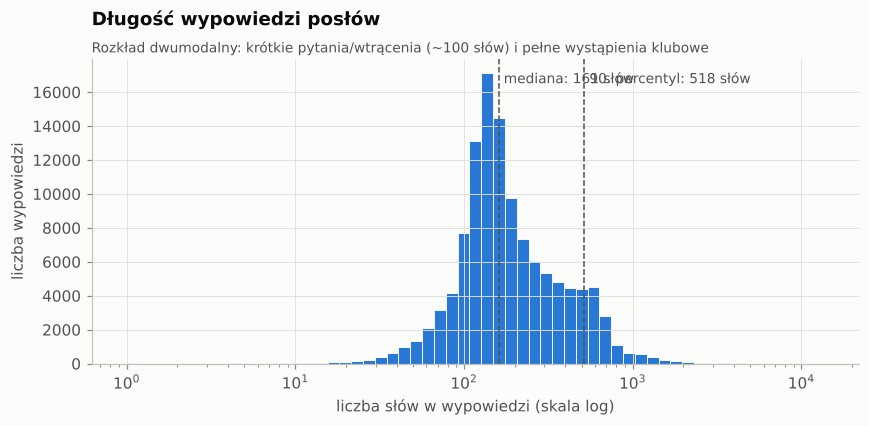

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
d = df.loc[(df["rola"] == "poseł") & (df["liczba_slow"] > 0), "liczba_slow"]
bins = np.logspace(0, np.log10(d.max() + 1), 60)
ax.hist(d, bins=bins, color=ACCENT, edgecolor=SURF, linewidth=0.6)
ax.set_xscale("log")
for q, lab in [(0.5, "mediana"), (0.9, "90. percentyl")]:
    v = d.quantile(q)
    ax.axvline(v, color=INK2, lw=1, ls="--")
    ax.text(v * 1.07, ax.get_ylim()[1] * 0.92, f"{lab}: {v:,.0f} słów", color=INK2, fontsize=9)
ax.set_xlabel("liczba słów w wypowiedzi (skala log)"); ax.set_ylabel("liczba wypowiedzi")
ax.set_title("Długość wypowiedzi posłów")
subtitle(ax, "Rozkład dwumodalny: krótkie pytania/wtrącenia (~100 słów) i pełne wystąpienia klubowe")
save(fig, "01_dlugosc_wypowiedzi"); plt.show()

## 2. Filtr wypowiedzi merytorycznych
Do analizy tematycznej zostawiamy wypowiedzi, które mogą nieść treść merytoryczną:
* bez bloku prowadzącego obrady (procedura, udzielanie głosu),
* co najmniej **40 słów** (odpada „Dziękuję”, wnioski formalne, krótkie wtrącenia),
* wypowiedzi niewygłoszone (oświadczenia złożone do protokołu) **zostają**, ale oznaczamy je — to też stanowisko posła.

In [7]:
MIN_SLOW = 40
kroki = [("wszystkie", df)]
x = df[df["rola"] != "prowadzący"]; kroki.append(("bez prowadzącego obrady", x))
x = x[x["liczba_slow"] >= MIN_SLOW]; kroki.append((f"≥ {MIN_SLOW} słów", x))
lejek = pd.DataFrame([(n, len(k), k["liczba_slow"].sum()) for n, k in kroki], columns=["krok", "wypowiedzi", "słowa"]).set_index("krok")
lejek["% wypowiedzi"] = lejek["wypowiedzi"] / lejek["wypowiedzi"].iloc[0] * 100
lejek["% słów"] = lejek["słowa"] / lejek["słowa"].iloc[0] * 100
display(lejek)
m = x.copy()  # m = korpus merytoryczny
print(f"Niewygłoszone w korpusie merytorycznym: {m['niewygloszona'].sum():,} ({m['niewygloszona'].mean():.1%})")

,wypowiedzi,słowa,% wypowiedzi,% słów
krok,,,,
wszystkie,130515,42037575,100.00,100.00
bez prowadzącego obrady,129890,36813593,99.52,87.57
≥ 40 słów,128190,36765233,98.22,87.46


Niewygłoszone w korpusie merytorycznym: 6,455 (5.0%)


## 3. Kluby → bloki polityczne
Nazwy klubów zmieniają się między kadencjami (PO → KO, PSL-KP → KP → PSL-TD, rozłamy...). Żeby porównywać trzy kadencje,
łączymy je w **bloki** o ciągłej tożsamości. Mapowanie jest jawne poniżej — łatwo je zmienić. Rozłamy przypisujemy do bloku macierzystego,
jeśli (prawie) wszyscy członkowie przyszli z jednego klubu (np. RozwojPlus → PiS, Centrum → Polska 2050); małe koła o mieszanym rodowodzie trafiają do „Inne / niez.”.

In [8]:
KLUB_BLOK = {
    # PiS; RozwojPlus = rozłam z klubu PiS w X kadencji (39 z 41 posłów przeszło z PiS)
    "PiS": "PiS", "RozwojPlus": "PiS",
    # KO; w VIII kadencji osobno PO i Nowoczesna (N), które weszły potem do KO
    "PO": "KO", "PO-KO": "KO", "KO": "KO", "N": "KO",
    "Lewica": "Lewica", "SLD": "Lewica", "LD": "Lewica", "PPS": "Lewica", "Razem": "Lewica", "Nowa_Lewica": "Lewica",
    "PSL": "PSL", "PSL-UED": "PSL", "PSL-KP": "PSL", "KP": "PSL", "PSL-Kukiz15": "PSL", "PSL-TD": "PSL",
    "Konfederacja": "Konfederacja", "Konfederacja_KP": "Konfederacja", "Wolnościowcy": "Konfederacja", "UPR": "Konfederacja",
    # Centrum = rozłam z Polski 2050 (wszyscy członkowie wcześniej w Polska2050)
    "Polska2050": "Polska 2050", "Polska2050-TD": "Polska 2050", "Centrum": "Polska 2050",
    "Kukiz15": "Kukiz'15",
    # pozostałe małe koła o mieszanym rodowodzie (WiS, UED, ED, L-S, TERAZ!, Republikanie, Demokracja, Porozumienie, PS...) -> Inne
}
m["blok"] = m["klub"].map(KLUB_BLOK)
m.loc[m["member_id"].gt(0) & m["blok"].isna(), "blok"] = "Inne / niez."
nieznane = m.loc[m["blok"].eq("Inne / niez."), "klub"].value_counts()
display(Markdown("**Kluby zaliczone do „Inne / niez.” (liczba wypowiedzi)**"), nieznane.to_frame().T)

kb = (m[m["member_id"] > 0].groupby(["kadencja", "blok"]).agg(poslowie=("member_id", "nunique"), wypowiedzi=("wypowiedz_id", "size"))
        .unstack(0).reindex(BLOKI).fillna(0).astype(int))
kb

**Kluby zaliczone do „Inne / niez.” (liczba wypowiedzi)**

klub,niez.,WiS,Republikanie,Demokracja,UED,Porozumienie,PS,ED,TERAZ!,L-S,W-S,PP
count,1807,880,680,496,181,100,93,77,73,43,18,3


poslowie           wypowiedzi              
kadencja           8    9    10         8      9      10
blok                                                    
PiS               260  237  198      14058  10366  15925
KO                172  137  173      18088  11204  12449
Kukiz'15           42    3    4       4445    284    304
Polska 2050         0    8   33          0   2025   3385
Lewica              0   49   29          0   7414   2809
PSL                23   30   33       3147   2754   2369
Konfederacja        7   13   21         57   2838   4058
Inne / niez.       39   21   15       1827    369   2255

## 4. Tematy
Każdą wypowiedź merytoryczną sprawdzamy słownikami. Rozróżniamy:
* **wzmiankę** — co najmniej 1 trafienie,
* **wypowiedź tematyczną** — co najmniej **3 trafienia** (temat jest istotnym wątkiem, a nie przelotnym odniesieniem).

Dodatkowo dwa wskaźniki przekrojowe: **`nauka`** (odwołania do naukowców, badań, WHO, PAN, konsensusu) i **`sceptycyzm`**
(zwroty dystansujące: „tzw. pandemia”, „eksperyment medyczny”, „segregacja sanitarna”, „klimatyzm”...).

In [9]:
%%time
flags = T.flag_topics(m["tekst"])
m = m.join(flags)
TEMATY = list(T.TOPICS)
PROG = 3
for t in TEMATY:
    m[f"{t}_tem"] = m[t] >= PROG
m["dowolny_tem"] = m[[f"{t}_tem" for t in TEMATY]].any(axis=1)

CPU times: user 6.24 s, sys: 2.79 ms, total: 6.25 s
Wall time: 6.54 s


In [10]:
podsum = pd.DataFrame({
    "wzmianki": [(m[t] > 0).sum() for t in TEMATY],
    "wypowiedzi tematyczne": [m[f"{t}_tem"].sum() for t in TEMATY],
    "mówcy (tematyczne)": [m.loc[m[f"{t}_tem"], "mowca"].nunique() for t in TEMATY],
    "słowa (tematyczne)": [m.loc[m[f"{t}_tem"], "liczba_slow"].sum() for t in TEMATY],
    "z odwołaniem do nauki": [(m[f"{t}_tem"] & (m["nauka"] > 0)).sum() for t in TEMATY],
    "ze zwrotem sceptycznym": [(m[f"{t}_tem"] & (m["sceptycyzm"] > 0)).sum() for t in TEMATY],
}, index=TEMATY).sort_values("wypowiedzi tematyczne", ascending=False)
podsum["% korpusu"] = podsum["wypowiedzi tematyczne"] / len(m) * 100
podsum.to_csv(PROC / "eda_tematy_podsumowanie.csv")
podsum

,wzmianki,wypowiedzi tematyczne,mówcy (tematyczne),słowa (tematyczne),z odwołaniem do nauki,ze zwrotem sceptycznym,% korpusu
covid,5493,1220,379,772196,35,13,0.95
szczepienia,1191,515,208,256645,25,10,0.40
klimat,2003,349,159,217252,15,20,0.27
energia_jadrowa,862,182,107,108118,3,1,0.14
smog,801,167,93,113960,10,0,0.13
in_vitro,624,153,100,63460,4,1,0.12
gmo,253,90,35,57931,5,0,0.07
5g_promieniowanie,98,20,13,14227,2,0,0.02


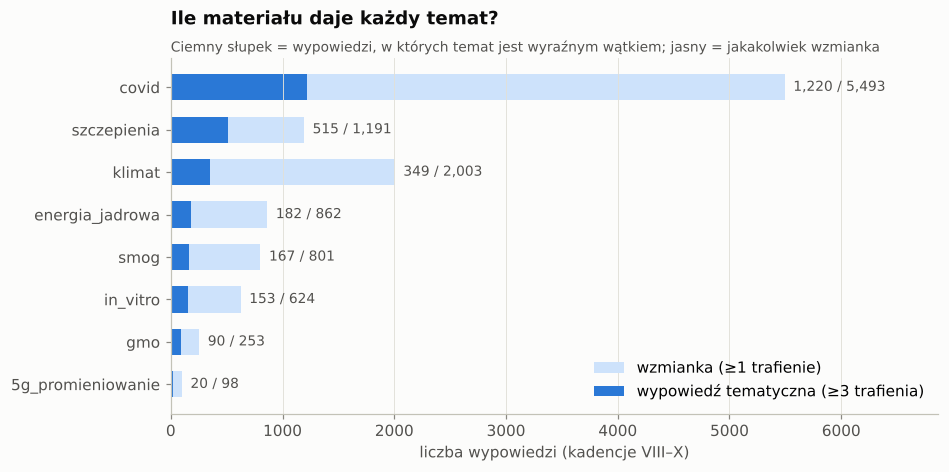

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.2))
p = podsum.sort_values("wypowiedzi tematyczne")
y = np.arange(len(p))
ax.barh(y, p["wzmianki"], color="#cde2fb", height=0.62, label="wzmianka (≥1 trafienie)")
ax.barh(y, p["wypowiedzi tematyczne"], color=ACCENT, height=0.62, label=f"wypowiedź tematyczna (≥{PROG} trafienia)")
for yi, (w, t) in enumerate(zip(p["wzmianki"], p["wypowiedzi tematyczne"])):
    ax.text(w, yi, f"  {t:,} / {w:,}", va="center", fontsize=9, color=INK2)
ax.set_yticks(y, p.index); ax.grid(axis="y", visible=False)
ax.set_xlabel("liczba wypowiedzi (kadencje VIII–X)")
ax.set_title("Ile materiału daje każdy temat?")
subtitle(ax, "Ciemny słupek = wypowiedzi, w których temat jest wyraźnym wątkiem; jasny = jakakolwiek wzmianka")
ax.legend(loc="lower right")
ax.set_xlim(0, p["wzmianki"].max() * 1.25)
save(fig, "02_tematy_skala"); plt.show()

### Tematy w podziale na kadencje
Liczba wypowiedzi tematycznych **na 1000 wypowiedzi merytorycznych** — normalizacja usuwa wpływ różnej liczby posiedzeń w kadencjach
(X kadencja jeszcze trwa).

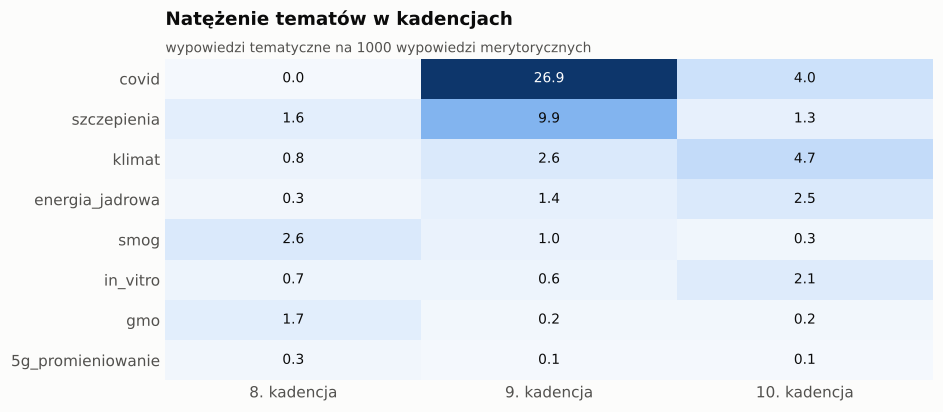

In [12]:
na_kad = (m.groupby("kadencja")[[f"{t}_tem" for t in TEMATY]].mean() * 1000).T
na_kad.index = TEMATY
na_kad = na_kad.loc[podsum.index]
fig, ax = plt.subplots(figsize=(9, 3.8))
im = ax.imshow(na_kad.values, cmap=SEQ, aspect="auto")
ax.set_xticks(range(len(TERMS)), [f"{t}. kadencja" for t in TERMS]); ax.set_yticks(range(len(na_kad)), na_kad.index)
ax.grid(False); ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
thr = na_kad.values.max() * 0.55
for i in range(na_kad.shape[0]):
    for j in range(na_kad.shape[1]):
        v = na_kad.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9, color="white" if v > thr else INK)
ax.set_title("Natężenie tematów w kadencjach")
subtitle(ax, "wypowiedzi tematyczne na 1000 wypowiedzi merytorycznych")
save(fig, "03_tematy_kadencje"); plt.show()

### Kontrola jakości słowników — przykładowe trafienia
Losowe fragmenty (±150 znaków wokół pierwszego trafienia). Przed właściwą analizą warto przejrzeć więcej przykładów i dopracować słowniki
(np. „szczepionki” łapią też szczepienia zwierząt — ASF, wścieklizna; „5G” łapie aukcję częstotliwości).

In [13]:
def kwic(text, rx, w=150):
    mm = rx.search(text.lower())
    if not mm:
        return ""
    s, e = max(0, mm.start() - w), min(len(text), mm.end() + w)
    return ("…" if s else "") + text[s:mm.start()] + "**" + text[mm.start():mm.end()] + "**" + text[mm.end():e] + ("…" if e < len(text) else "")

def przyklady(maska, rx, n=4, seed=1):
    s = m[maska].sample(min(n, maska.sum()), random_state=seed)
    out = []
    for _, r in s.iterrows():
        frag = kwic(r["tekst"], rx).replace("\n", " ")
        kto = r["klub"] if isinstance(r["klub"], str) else r["rola"]
        out.append(f"- *{r['mowca']} ({kto}), {r['data']:%Y-%m-%d}:* {frag}")
    return "\n".join(out)

for t in podsum.index:
    display(Markdown(f"#### {t}\n" + przyklady(m[f"{t}_tem"], T.TOPIC_RE[t])))

#### covid
- *Grzegorz Adam Płaczek (Konfederacja), 2023-12-11:* …t premier naszego kraju.  Panie Premierze! Mam do pana pytania w imieniu tych wszystkich milionów Polaków, którzy przez 2 lata, w okresie bezprawnego **lockdownu** wprowadzonego przez pana rząd, byli traktowani jak obywatele państwa totalitarnego. Chciałbym, aby moje słowa były głosem kilku milionów Polaków, któ…
- *Mateusz Morawiecki (PiS), 2021-05-04:* …my raz jeszcze głośne ˝tak˝ dla rozwoju Polski, głośne ˝tak˝ dla rozkwitu Polski, również dzięki środkom unijnym. To duża szansa na szybkie wyjście z **pandemii**, szybkie wyjście z COVID-19.     I dlatego pozwólcie, szanowni państwo, że na początku powiem kilka zdań o całym procesie, bo głosy na ten temat też …
- *Marek Rutka (Lewica), 2021-06-23:* Pani Marszałek! Pani Minister! Wysoka Izbo! W związku z negatywnymi skutkami rozprzestrzeniania się epidemii **COVID**-19 kluczowe znaczenie mają wszelkie działania stymulujące konkurencyjność i innowacyjność przemysłu farmaceutycznego. Wobec tego mam pytanie: Czy Age…
- *Jacek Protas (KO), 2020-10-21:* …iat, a właścicielem szpitali wojewódzkich - województwo. Szanowni Państwo! Padło pytanie o zaangażowanie samorządów terytorialnych w przeciwdziałanie **pandemii**. Po pierwsze, chcę powiedzieć, że zanim powstały jakiekolwiek ustawy anty-COVID-owe, większość polskich gmin, miast wprowadziła dla przedsiębiorców z…

#### szczepienia
- *Justyna Anna Socha (inni), 2018-10-03:* … też, podobnie jak pan minister Pinkas, mam misję, misję polegającą na zapewnieniu zdrowia i bezpieczeństwa dzieci, zaczynając od moich dzieci, które **szczepiłam**. Większość z nas szczepiła swoje dzieci, ufnie wierzyła w ten system, więc nieuprawnione jest nazywanie nas ruchem antyszczepionkowym. Chcę przede ws…
- *Magdalena Biejat (Lewica), 2021-12-01:* …ali i, co więcej, one trafiają tam w coraz gorszym stanie. Jedyną szansą na chronienie ich zdrowia i życia jest wyszczepienie wszystkich tych, którzy **szczepić** się mogą. Tymczasem rząd woli kłaniać się antyszczepionkowcom, którzy dziś trzęsą Ministerstwem Zdrowia, i udaje, że kilkaset osób zmarłych dziennie …
- *Anna Goławska (rząd), 2021-07-23:* …nformacji negatywnych pojawiło się w wypowiedziach państwa posłów. Oczywiście one nie zawsze mają odzwierciedlenie w rzeczywistości, ponieważ program **szczepień** jest realizowany w sposób ciągły, w sposób niezakłócony. Początkowe problemy miały miejsce w związku z dostawami szczepionek i były niezależne od rzą…
- *Jan Szopiński (Lewica), 2021-04-14:* …uprzejmą prośbę do pani. Uprzejmie proszę, aby możliwie pilnie przedłożyła pani poprawki, które zostały złożone przez posłów PiS w kwestii dotyczącej **szczepień**. Komisja edukacji zajmująca się szczepieniami to chyba kuriozum w Wysokiej Izbie, skoro wczoraj obradowała Komisja Zdrowia i zajmowała się kwestią do…

#### klimat
- *Krzysztof Bosak (Konfederacja), 2024-04-26:* Pani Marszałek! Wysoki Sejmie! Nasze pytania w sprawie Europejskiego **Zielonego Ładu**, widać, wzbudziły duże emocje w ławach PiS-owskich, i to nie przypadek. Bo PiS ma dużo na sumieniu i musi teraz włożyć ogromną energię w to, żeby zak…
- *Jerzy Meysztowicz (KO), 2025-02-05:* …ak się często zmienia ugrupowanie polityczne, to czasami trzeba sprawdzić, gdzie się ląduje.   Pan jest jednym z największych przeciwników i krytyków **zielonego ładu**. Nie zwrócił pan jednak uwagi na to, że wylądował pan w ugrupowaniu, które przez pewien czas prezentowało zielony ład jako swój wspaniały program, że…
- *Krzysztof Mulawa (Konfederacja), 2024-03-20:* …- dotyczącej pełnego i bezcłowego otwarcia polskiej granicy na towary z Ukrainy. Teraz rolnicy, szanowni państwo, skupiają swoją uwagę na Europejskim **Zielonym Ładzie**. Widzą pozorowane ruchy premiera Tuska i obawiają się, że ich gospodarstwa zostaną zmiecione z powierzchni ziemi przez pana premiera Tuska oraz zielo…
- *Gabriela Lenartowicz (KO), 2021-09-29:* …ej dziury. W tej ustawie nie ma znaczenia pieniędzy. Chociaż dyrektywy, rozporządzenie i nasza ustawa mówią, że co najmniej 50% trzeba przeznaczyć na **politykę klimatyczną**, to jednak te pieniądze nie są znaczone i niewiadome jest ich wydatkowanie. Twórczość w zakresie sprawozdawczości, na co są one przeznaczone, jest da…

#### energia_jadrowa
- *Paulina Matysiak (Lewica), 2022-11-15:* Dziękuję. Panie Marszałku! Wysoka Izbo! Potrzebujemy w Polsce **elektrowni jądrowych** - to chyba dla nas wszystkich jest jasne. Energia z elektrowni jądrowej to tanie, bezpieczne i niskoemisyjne, co w kontekście katastrofy klimatycznej…
- *Maciej Konieczny (Lewica), 2024-07-11:* …cji budynków. Efekt tego jest taki, że nie dość, że mamy drogą energię, to jeszcze ją marnujemy. PiS również zdecydowanie za późno postawił na budowę **elektrowni jądrowej**. Niestety wszystkie działania i deklaracje nowego rządu w tej kwestii także nie dają nam gwarancji, że te elektrownie jądrowe powstaną, a potrzebujem…
- *Wojciech Wrochna (rząd), 2024-12-19:* …arszałek! Wysoka Izbo! Postaram się odpowiedzieć dosyć krótko i spójnie, adresując kilka punktów. Na początek powiem o ogólnym i spójnym podejściu do **energetyki jądrowej**, jakie musimy zastosować po to, żeby jakikolwiek projekt mógł w Polsce zostać zrealizowany. Pamiętajmy o tym, że energetyka jądrowa to są najbardziej…
- *Joanna Wicha (Lewica), 2025-02-20:* Panie Marszałku! Wysoka Izbo! Polski program **energetyki jądrowej** to historia sięgająca dalej niż pół wieku. Już od ponad 50 lat Polska stara się zrealizować ambitny projekt budowy elektrowni jądrowej. Niestety dopi…

#### smog
- *Sylwester Chruszcz (WiS), 2017-12-13:* … badań powietrza atmosferycznego wykonywanych przez wojewódzkie inspektoraty ochrony środowiska i przekazanie rzetelnej informacji o aktualnym stanie **jakości powietrza** na obszarze Polski oraz w konsekwencji - określenie i realizację skutecznych działań naprawczych w ramach programów ochrony powietrza mających na cel…
- *Maciej Masłowski (Kukiz15), 2018-03-06:* …ieszkańców Mielca jest to temat bardzo ważny i każdy dzień ma olbrzymie znaczenie, dlatego też wykorzystuję tę formę, aby zaapelować do pana o pomoc. **Jakość powietrza** w Polsce jest tragiczna. Sami na to pozwalamy. Polska ma najbardziej liberalne zasady co do informowania społeczeństwa o zanieczyszczeniu powietrza s…
- *Bogusław Sonik (KO), 2022-06-09:* …jących z funkcjonowania w Polsce systemu oceny i zarządzania jakością powietrza, chciałem zwrócić uwagę na dwie kwestie. Po pierwsze, kwestię poprawy **jakości powietrza** w Polsce. W zeszłej kadencji byłem przewodniczącym Parlamentarnego Zespołu na rzecz poprawy jakości powietrza, tzw. Antysmogowego. Walka ze smogiem z…
- *Rafał Trzaskowski (PO), 2018-06-07:* …im mam pytanie do posłanki sprawozdawcy. Czego się boicie w ustawie, która ma pozwolić samorządom i w ogóle generalnie w Polsce efektywnie walczyć ze **smogiem**? Wielu waszych kandydatów na prezydentów występuje przed kamerami i opowiada o tym, że będzie walczyć ze smogiem, a teraz chcecie odrzucić w pierwszy…

#### in_vitro
- *Monika Wielichowska (KO), 2023-11-22:* …alił się świat, bo straciły szansę na bycie matką, na macierzyństwo. Ludziom zawalił się świat, bo stracili szansę na upragnione rodzicielstwo. Kiedy **in vitro**, najskuteczniejsza metoda wspierająca walkę z niepłodnością, przestało być finansowane z budżetu państwa, niektóre samorządy zaczęły zastępować państ…
- *Ryszard Wilczyński (KO), 2021-06-24:* …a nie oficerem propagandy swojej partii. Powinna pani za to przeprosić, naprawdę, albo już więcej tak nie mówić, bo to rzeczywiście wstyd. Nakłady na **in vitro**. Program in vitro rozwiązał problem ubóstwa, ale w sensie demograficznym urodzenie jednego dziecka ekstra to jest 1350 tys. zł. W programie in vitro …
- *Bartosz Arłukowicz (KO), 2023-11-22:* …takie momenty, które pamięta się do końca życia. Takim momentem było dla mnie, po uzgodnieniu z panem premierem Donaldem Tuskiem, podpisanie programu **in vitro**.   Z tego programu urodziło się 22 tys. dzieci. Czyli 22 tys. rodzin, które walczyły o dziecko, miało do tego prawo i taką możliwość. I przyszedł ten…
- *Piotr Kaleta (PiS), 2023-11-29:* Bardzo dziękuję. Pani Marszałek! Wysoka Izbo! Pytanie zasadnicze, które tu powinno paść, a nie pada: Czy **in vitro** w Polsce jest zabronione? Otóż nie. Nawiązując do wypowiedzi niektórych z państwa, chciałbym powiedzieć o jednej rzeczy. Naprotechnologia stawia na n…

#### gmo
- *Stefan Romecki (Kukiz15), 2018-11-21:* Pani Marszałek! Wysoka Izbo! To kolejne już moratorium odkładające na nigdy wejście w życie przepisów zakazujących importu pasz **GMO**. Mimo obietnic sprzed 2 lat nie podjęto wystarczających starań, aby zwiększyć udział krajowego białka w rolnictwie. Brak konkretnego programu z okreś…
- *Hanna Gill-Piątek (Polska2050), 2022-11-30:* …s energetyczny, zawsze wtedy głosujemy za przedłużeniem terminów. Tak pewnie podchodzilibyśmy do sprawy opóźnienia zakazu używania importowanych pasz **GMO**, ale w tym przypadku sytuacja nie jest ani nowa, ani nagła. Ile razy bowiem można przedłużać przejście na... Pan mnie słucha? Wicemarszałek Włodzimie…
- *Stefan Niesiołowski (UED), 2017-09-27:* … to machanie łapami nie pomoże panu - mieszkają w namiotach. Tak że bardzo chętnie bym usłyszał, czy to prawda, czy to nieprawda. Jeszcze króciutko o **GMO**. Panowie, tutaj jedyna moja taka drobna uwaga: GMO to jest wszystko. Zboża, owoce, rośliny, mięso - to wszystko jest GMO. Czyli wy się na coś zdecydu…
- *Dorota Niedziela (PO), 2018-11-21:* …aźnie zapisane - przypomnę, że chodzi o 2014 r.- że należy opracować i wdrożyć instytucjonalne zintegrowanie programu wytwarzania pasz białkowych bez **GMO**, przetwórstwa i wprowadzenie na rynek specjalnego oznakowania dla produktów GMO. Przypomnę, że taki program istniał i działał od 2010 r., był utworzo…

#### 5g_promieniowanie
- *Marek Wójcik (PO-KO), 2019-01-16:* …ktem operatorzy telekomunikacyjni nie będą mogli instalować nadajników w promieniu 500 m od urządzeń pomiarowych. Tymczasem właśnie w przypadku sieci **5G** zagęszczenie nadajników musi być znacznie większe niż w przypadku technologii, które są stosowane obecnie. I tutaj pojawiły się wątpliwości dotyczące…
- *Adam Dziedzic (PSL-TD), 2024-06-13:* …stawie wprowadzającej właśnie ustawę - Prawo komunikacji elektronicznej. Projekt realizuje kamień milowy służący likwidacji barier we wdrażaniu sieci **5G** w ramach reformy Krajowego Planu Odbudowy i Zwiększania Odporności. Ustawa w art. 1 reguluje termin wejścia w życie tzw. ustawy głównej tj. ustawy - …
- *Antoni Mężydło (PO-KO), 2019-01-30:* …er! Myślę, że wada tej ustawy i te wszystkie wady, które zostały tu wytknięte, wynikają z jednego - z tego, że rząd nie zrealizował strategii rozwoju **5G**. Gdyby była cała strategia 5G, to nie trzeba by było sobie zostawiać tych nadzwyczajnych narzędzi, które rząd chce mieć, czyli wyręczyć, jeśli chodzi…
- *Wanda Buk (rząd), 2019-07-03:* …ast jest to tylko jeden z elementów. Będziemy oczywiście dalej walczyć z dezinformacją. Pan poseł Gonciarz skonkludował, że ludzie obawiają się sieci **5G**, i zapytał, czy mamy wiedzę, jak w innych krajach wygląda wprowadzanie sieci piątej generacji i czy jest szansa na to, że normy będą ujednolicone na …

## 5. Trend w czasie
Czy liczba wypowiedzi zależy od czasu? Pokazujemy dwie rzeczy:
1. **wolumen** — ile w ogóle jest wypowiedzi merytorycznych w miesiącu (zależy od kalendarza posiedzeń, wakacji, kampanii),
2. **udział tematu** — wypowiedzi tematyczne na 1000 wypowiedzi w miesiącu (to właściwa miara „zainteresowania” tematem).

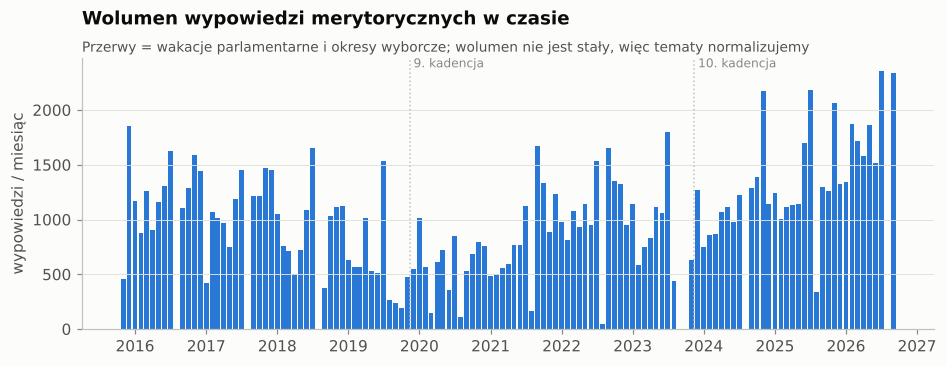

In [14]:
mies = m.groupby("miesiac").size().rename("wypowiedzi")
# pełna oś miesięcy: miesiące bez posiedzeń = brak danych (przerwa na wykresie), a nie zero
mies = mies.reindex(pd.date_range(mies.index.min(), mies.index.max(), freq="MS"))
GRANICE = {9: pd.Timestamp("2019-11-12"), 10: pd.Timestamp("2023-11-13")}
WYDARZENIA = {pd.Timestamp("2020-03-01"): "COVID-19 w Polsce", pd.Timestamp("2022-02-24"): "inwazja na Ukrainę"}

def kadencje_tlo(ax, label=True):
    for t, d in GRANICE.items():
        ax.axvline(d, color=AXIS, lw=1, ls=":")
        if label:
            ax.text(d, 1.0, f" {t}. kadencja", transform=ax.get_xaxis_transform(), fontsize=8, color=MUTED, va="top")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(mies.index, mies.fillna(0).values, width=25, color=ACCENT)
kadencje_tlo(ax)
ax.set_ylabel("wypowiedzi / miesiąc"); ax.grid(axis="x", visible=False)
ax.set_title("Wolumen wypowiedzi merytorycznych w czasie")
subtitle(ax, "Przerwy = wakacje parlamentarne i okresy wyborcze; wolumen nie jest stały, więc tematy normalizujemy")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
save(fig, "04_wolumen"); plt.show()

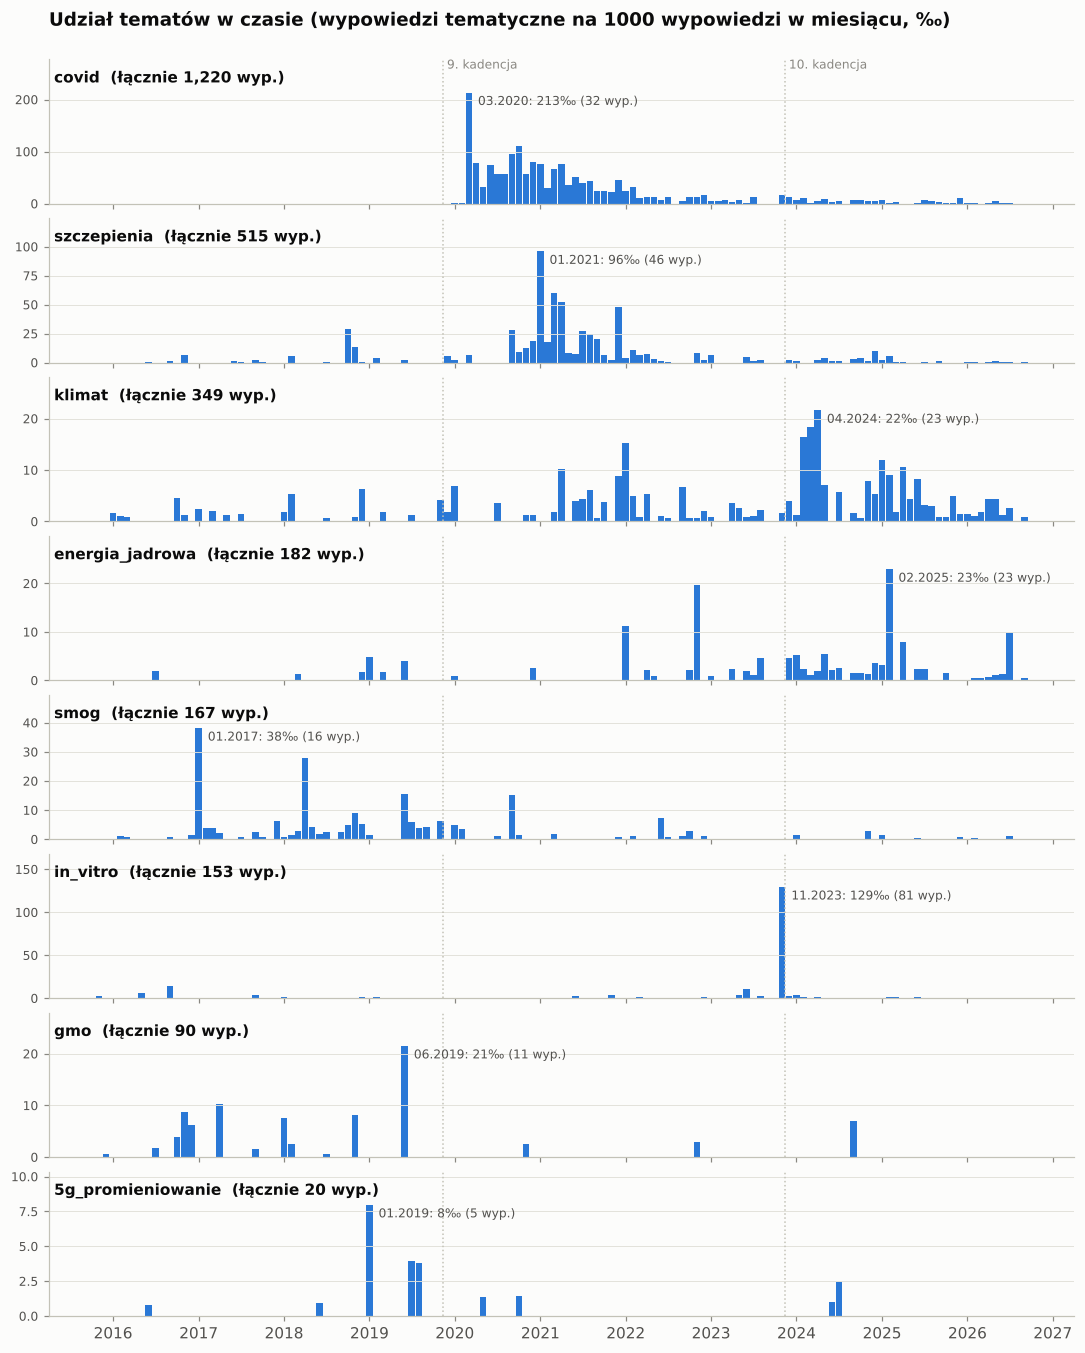

In [15]:
udz = m.groupby("miesiac")[[f"{t}_tem" for t in TEMATY]].sum()
udz.columns = TEMATY
udz = udz.reindex(mies.index)
udz_1000 = udz.div(mies, axis=0) * 1000
udz_1000.to_csv(PROC / "eda_tematy_miesiecznie_na1000.csv")
udz.to_csv(PROC / "eda_tematy_miesiecznie_liczby.csv")

kol = list(podsum.index)
fig, axes = plt.subplots(len(kol), 1, figsize=(10, 1.55 * len(kol)), sharex=True)
for ax, t in zip(axes, kol):
    s = udz_1000[t]
    ax.bar(s.index, s.fillna(0).values, width=28, color=ACCENT)
    kadencje_tlo(ax, label=(ax is axes[0]))
    ax.set_ylim(0, max(s.max() * 1.3, 1))
    ax.text(0.005, 0.92, f"{t}  (łącznie {int(udz[t].sum()):,} wyp.)", transform=ax.transAxes, fontsize=10, fontweight="bold", color=INK, va="top")
    if not s.max() > 0:
        continue
    top = s.idxmax()
    ax.annotate(f"{top:%m.%Y}: {s.max():.0f}‰ ({udz.loc[top, t]:.0f} wyp.)", xy=(top, s.max()), xytext=(6, -2),
                textcoords="offset points", fontsize=8, color=INK2, va="top")
    ax.tick_params(axis="y", labelsize=8); ax.grid(axis="x", visible=False)
axes[0].set_title("Udział tematów w czasie (wypowiedzi tematyczne na 1000 wypowiedzi w miesiącu, ‰)")
axes[-1].xaxis.set_major_locator(mdates.YearLocator()); axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout(h_pad=0.4)
save(fig, "05_tematy_w_czasie"); plt.show()

### Co stoi za pikami?
Dla każdego tematu: trzy miesiące o najwyższym udziale oraz dni posiedzeń, w których padło najwięcej wypowiedzi tematycznych.
Piki zwykle odpowiadają konkretnemu projektowi ustawy — wtedy kilkudziesięciu posłów wypowiada się w jednej debacie.

In [16]:
wiersze = []
for t in kol:
    top_m = udz_1000[t].nlargest(3)
    dni = m[m[f"{t}_tem"]].groupby(m["data"].dt.date).size().nlargest(3)
    wiersze.append({
        "temat": t,
        "top miesiące (‰)": ", ".join(f"{d:%Y-%m} ({v:.0f})" for d, v in top_m.items()),
        "top dni (liczba wyp.)": ", ".join(f"{d} ({v})" for d, v in dni.items()),
        "udział 3 najlepszych dni w temacie": f"{dni.sum() / m[f'{t}_tem'].sum():.0%}",
    })
pd.DataFrame(wiersze).set_index("temat")

,top miesiące (‰),top dni (liczba wyp.),udział 3 najlepszych dni w temacie
temat,,,
covid,"2020-03 (213), 2020-10 (111), 2020-09 (96)","2021-04-15 (39), 2020-09-17 (37), 2021-01-21 (36)",9%
szczepienia,"2021-01 (96), 2021-03 (60), 2021-04 (53)","2021-01-21 (46), 2021-09-15 (30), 2021-07-23 (29)",20%
klimat,"2024-04 (22), 2024-03 (18), 2024-02 (16)","2024-04-26 (19), 2024-11-27 (12), 2024-02-22 (11)",12%
energia_jadrowa,"2025-02 (23), 2022-11 (20), 2022-01 (11)","2022-11-15 (23), 2025-02-20 (21), 2026-07-01 (19)",35%
smog,"2017-01 (38), 2018-04 (28), 2019-06 (16)","2017-01-26 (14), 2018-04-13 (12), 2017-12-13 (7)",20%
in_vitro,"2023-11 (129), 2016-09 (15), 2023-06 (10)","2023-11-22 (54), 2023-11-29 (26), 2016-09-22 (15)",62%
gmo,"2019-06 (21), 2017-04 (10), 2016-11 (9)","2019-06-12 (11), 2017-04-06 (10), 2016-11-03 (9)",33%
5g_promieniowanie,"2019-01 (8), 2019-07 (4), 2019-08 (4)","2019-07-03 (4), 2019-01-16 (3), 2024-07-11 (3)",50%


In [17]:
# Trend długookresowy: roczne natężenie tematów (pomijamy niepełne lata na brzegach tylko w interpretacji)
roczne = (m.groupby("rok")[[f"{t}_tem" for t in TEMATY]].mean() * 1000)
roczne.columns = TEMATY
display(Markdown("**Wypowiedzi tematyczne na 1000 wypowiedzi merytorycznych — wg roku**"))
roczne[kol].round(1)

**Wypowiedzi tematyczne na 1000 wypowiedzi merytorycznych — wg roku**

,covid,szczepienia,klimat,energia_jadrowa,smog,in_vitro,gmo,5g_promieniowanie
rok,,,,,,,,
2015,0.00,0.00,0.00,0.00,0.00,0.90,0.40,0.00
2016,0.00,0.90,0.90,0.20,0.40,1.70,2.30,0.10
2017,0.00,0.60,0.50,0.00,3.30,0.30,1.00,0.00
2018,0.00,5.00,1.50,0.30,4.80,0.20,2.00,0.10
2019,0.00,0.90,0.90,0.90,3.30,0.10,1.60,1.70
2020,58.70,6.70,1.70,0.40,2.40,0.00,0.30,0.30
2021,39.90,26.80,3.30,0.00,0.20,0.60,0.00,0.00
2022,13.40,3.50,3.30,3.40,1.30,0.20,0.30,0.00
2023,7.80,2.00,1.80,1.60,0.00,10.40,0.00,0.00


## 6. Partie
Kto mówi o tych tematach? Uwzględniamy tylko posłów (mają przypisany klub w dniu wypowiedzi).

**Miara:** liczba wypowiedzi tematycznych bloku **na 1000 wypowiedzi merytorycznych tego bloku**. Dzięki temu duży klub
nie wygrywa samą liczebnością — widać, *który klub poświęca tematowi proporcjonalnie więcej uwagi*.

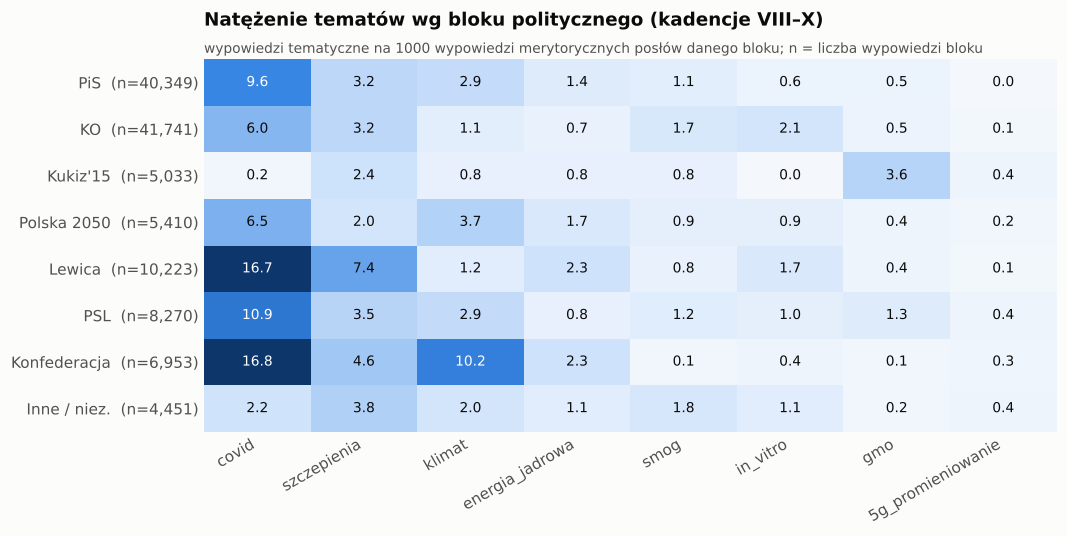

In [18]:
p = m[m["member_id"] > 0]
blok_tem = (p.groupby("blok")[[f"{t}_tem" for t in TEMATY]].mean() * 1000)
blok_tem.columns = TEMATY
blok_tem = blok_tem.reindex([b for b in BLOKI if b in blok_tem.index])[kol]
blok_n = p.groupby("blok").size().reindex(blok_tem.index)
blok_tem.to_csv(PROC / "eda_tematy_bloki_na1000.csv")

fig, ax = plt.subplots(figsize=(10, 4.4))
v = blok_tem.values
im = ax.imshow(v, cmap=SEQ, aspect="auto", vmin=0)
ax.set_xticks(range(len(kol)), kol, rotation=30, ha="right")
ax.set_yticks(range(len(blok_tem)), [f"{b}  (n={blok_n[b]:,})" for b in blok_tem.index])
ax.grid(False); ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
for i in range(v.shape[0]):
    for j in range(v.shape[1]):
        # kolumny mają różne skale — próg kontrastu liczymy per kolumna
        ax.text(j, i, f"{v[i, j]:.1f}", ha="center", va="center", fontsize=9,
                color="white" if v[i, j] > v.max() * 0.55 else INK)
ax.set_title("Natężenie tematów wg bloku politycznego (kadencje VIII–X)")
subtitle(ax, "wypowiedzi tematyczne na 1000 wypowiedzi merytorycznych posłów danego bloku; n = liczba wypowiedzi bloku")
save(fig, "06_tematy_bloki"); plt.show()

Heatmapa ma wspólną skalę, więc duże tematy (COVID, klimat) dominują kolorem. Poniżej ten sam wynik **indeksowany per temat**:
1,0 = średnia wszystkich posłów; >1 = blok mówi o temacie częściej niż przeciętnie.

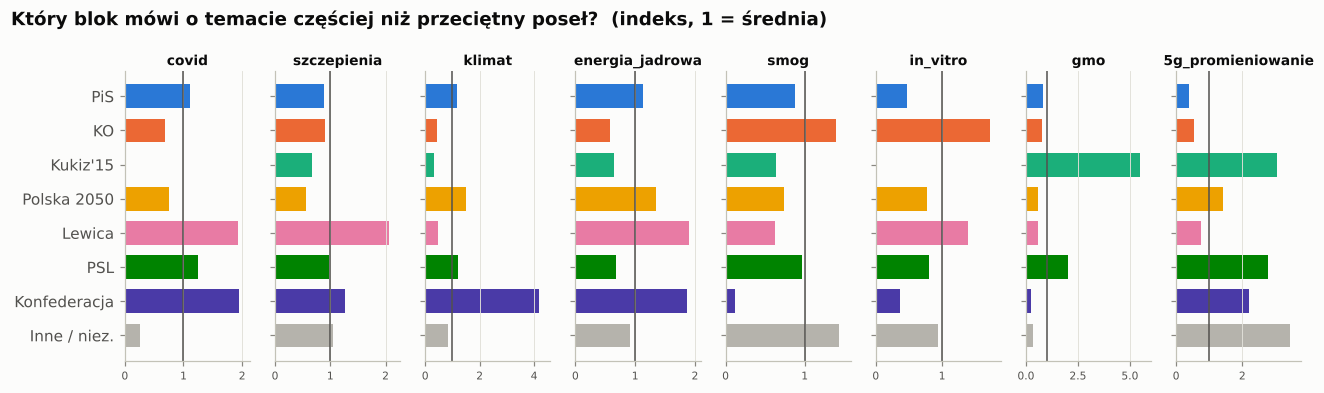

In [19]:
srednia = p[[f"{t}_tem" for t in kol]].mean().values * 1000
idx = (blok_tem / np.where(srednia > 0, srednia, np.nan)).fillna(0)
fig, axes = plt.subplots(1, len(kol), figsize=(12, 3.6), sharey=True)
y = np.arange(len(idx))
for ax, t in zip(axes, kol):
    ax.barh(y, idx[t], color=[BLOK_KOLOR[b] for b in idx.index], height=0.7)
    ax.axvline(1, color=INK2, lw=1)
    ax.set_title(t, fontsize=9, loc="center", pad=4)
    ax.grid(axis="y", visible=False); ax.tick_params(axis="x", labelsize=7)
    ax.set_xlim(0, max(idx[t].max() * 1.1, 1.5))
axes[0].set_yticks(y, idx.index); axes[0].invert_yaxis()
fig.suptitle("Który blok mówi o temacie częściej niż przeciętny poseł?  (indeks, 1 = średnia)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "07_indeks_bloki"); plt.show()

### Udział bloków w wypowiedziach tematycznych, wg kadencji
Kto *faktycznie* produkuje materiał w danym temacie (liczby bezwzględne) — ważne przy planowaniu próby do anotacji.

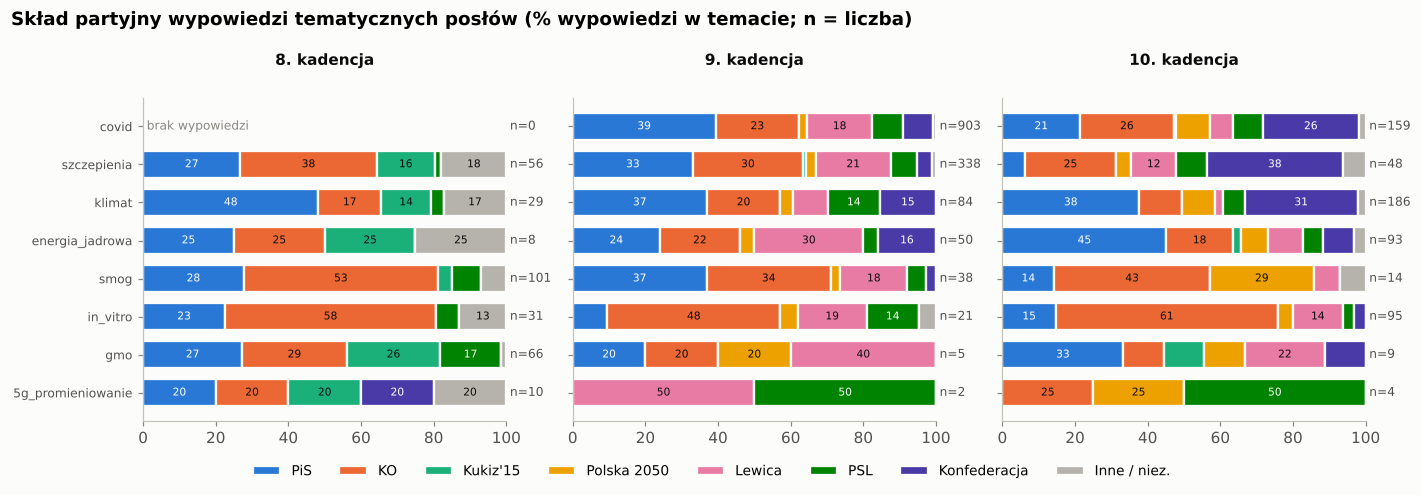

In [20]:
fig, axes = plt.subplots(1, len(TERMS), figsize=(13, 4.2), sharey=True)
for ax, k in zip(axes, TERMS):
    pk = p[p["kadencja"] == k]
    tab = pd.DataFrame({t: pk.loc[pk[f"{t}_tem"], "blok"].value_counts(normalize=True) for t in kol}).T.reindex(kol).fillna(0)
    tab = tab[[b for b in BLOKI if b in tab.columns]] * 100
    left = np.zeros(len(tab))
    for b in tab.columns:
        ax.barh(range(len(tab)), tab[b], left=left, color=BLOK_KOLOR[b], height=0.7, edgecolor=SURF, linewidth=1.5, label=b)
        for i, (l, w) in enumerate(zip(left, tab[b])):
            if w >= 12:
                ax.text(l + w / 2, i, f"{w:.0f}", ha="center", va="center", fontsize=7, color="white" if b in ("PiS", "Konfederacja", "PSL") else INK)
        left += tab[b].values
    for i, t in enumerate(tab.index):
        n = pk[f"{t}_tem"].sum()
        if n == 0:
            ax.text(1, i, "brak wypowiedzi", va="center", fontsize=8, color=MUTED)
        ax.text(101, i, f"n={n}", va="center", fontsize=8, color=INK2)
    ax.set_yticks(range(len(tab)), tab.index)
    ax.set_title(f"{k}. kadencja", fontsize=10, loc="center"); ax.set_xlim(0, 100); ax.grid(False)
    ax.tick_params(axis="y", labelsize=8)
axes[0].invert_yaxis()
h, l = [], []
for ax in axes:
    for hh, ll in zip(*ax.get_legend_handles_labels()):
        if ll not in l: h.append(hh); l.append(ll)
order = [l.index(b) for b in BLOKI if b in l]
fig.legend([h[i] for i in order], [l[i] for i in order], loc="lower center", ncol=len(order), bbox_to_anchor=(0.5, -0.06), fontsize=9)
fig.suptitle("Skład partyjny wypowiedzi tematycznych posłów (% wypowiedzi w temacie; n = liczba)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
save(fig, "08_sklad_partyjny"); plt.show()

### Najaktywniejsi mówcy w każdym temacie

In [21]:
naj = []
for t in kol:
    s = m[m[f"{t}_tem"]].groupby(["mowca"]).agg(wyp=("wypowiedz_id", "size"), klub=("klub", lambda x: "/".join(sorted({v for v in x if isinstance(v, str)}))))
    s = s.sort_values("wyp", ascending=False).head(5)
    naj.append({"temat": t, "top 5 mówców (liczba wypowiedzi)": "; ".join(f"{i} [{r.klub or '–'}] {r.wyp}" for i, r in s.iterrows()),
                "udział top 5": f"{s['wyp'].sum() / m[f'{t}_tem'].sum():.0%}"})
pd.DataFrame(naj).set_index("temat")

,top 5 mówców (liczba wypowiedzi),udział top 5
temat,,
covid,Grzegorz Braun [Konfederacja] 21; Waldemar Kraska [–] 21; Władysław Kosiniak-Kamysz [KP/PSL-Kukiz15/PSL-TD] 18; Henryk Kowalczyk [PiS] 17; Mateusz Morawiecki [PiS] 17,8%
szczepienia,Waldemar Kraska [–] 19; Zdzisław Wolski [Lewica] 14; Katarzyna Lubnauer [KO] 12; Jan Szopiński [Lewica] 9; Józefa Szczurek-Żelazko [PiS] 9,12%
klimat,Witold Tumanowicz [Konfederacja] 19; Urszula Zielińska [KO] 10; Paweł Sałek [PiS] 9; Janusz Kowalski [PiS] 8; Michał Woś [PiS] 8,15%
energia_jadrowa,Miłosz Motyka [–] 8; Wojciech Wrochna [–] 8; Maciej Konieczny [Lewica/Razem] 6; Patryk Wicher [PiS] 5; Tomasz Piotr Nowak [KO] 5,18%
smog,Gabriela Lenartowicz [KO/PO/PO-KO] 10; Ireneusz Zyska [PiS/WiS] 7; Małgorzata Golińska [PiS] 6; Anna Paluch [PiS] 5; Alicja Chybicka [PO/PO-KO] 5,20%
in_vitro,Bartosz Arłukowicz [KO/PO/PO-KO] 11; Monika Wielichowska [KO/PO] 6; Agnieszka Pomaska [KO/PO] 5; Barbara Nowacka [KO] 4; Wanda Nowicka [Lewica] 4,20%
gmo,Jarosław Sachajko [Kukiz15] 12; Dorota Niedziela [PO/PO-KO] 9; Mirosław Maliszewski [PSL/PSL-UED] 9; Norbert Kaczmarczyk [Kukiz15] 5; Robert Telus [PiS] 4,43%
5g_promieniowanie,Robert Majka [Konfederacja/niez.] 4; Wanda Buk [–] 3; Jarosław Sachajko [Kukiz15/PSL-Kukiz15] 2; Adam Dziedzic [PSL-TD] 2; Anna Streżyńska [–] 1,60%


## 7. Nauka i sceptycyzm — wstępne rozpoznanie
To **nie jest** jeszcze klasyfikacja zgodności z konsensusem — to sprawdzenie, czy w danych w ogóle występuje materiał, na którym
taka klasyfikacja ma sens:
* jak często w wypowiedziach tematycznych mówcy **powołują się na naukę**,
* jak często pojawiają się **zwroty podważające** (marker potencjalnej sprzeczności z konsensusem),
* czy te markery różnicują bloki polityczne.

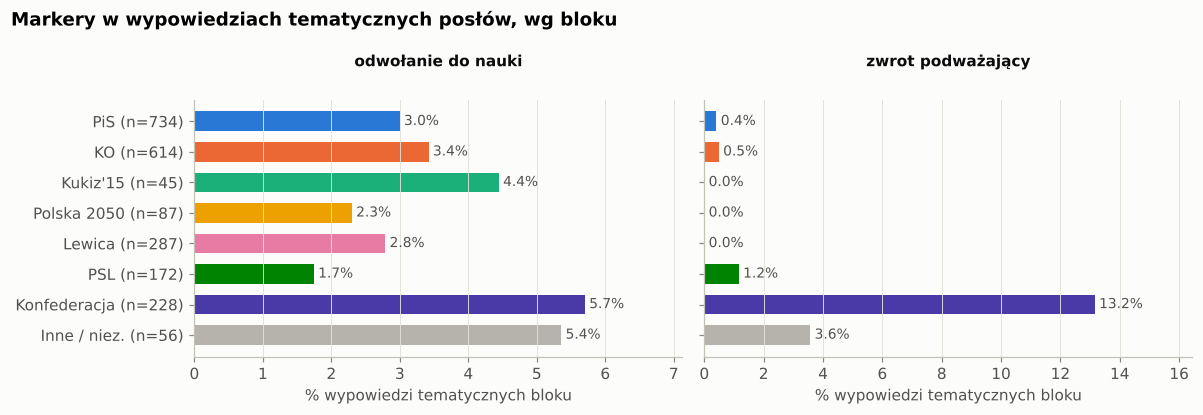

In [22]:
tem = p[p["dowolny_tem"]]
mark = tem.groupby("blok").agg(
    wypowiedzi_tematyczne=("wypowiedz_id", "size"),
    nauka_pct=("nauka", lambda x: (x > 0).mean() * 100),
    sceptycyzm_pct=("sceptycyzm", lambda x: (x > 0).mean() * 100),
).reindex([b for b in BLOKI if b in tem["blok"].unique()])
mark.to_csv(PROC / "eda_markery_bloki.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
y = np.arange(len(mark))
for ax, col, title in [(axes[0], "nauka_pct", "odwołanie do nauki"), (axes[1], "sceptycyzm_pct", "zwrot podważający")]:
    ax.barh(y, mark[col], color=[BLOK_KOLOR[b] for b in mark.index], height=0.65)
    for yi, v in enumerate(mark[col]):
        ax.text(v, yi, f" {v:.1f}%", va="center", fontsize=9, color=INK2)
    ax.set_title(title, fontsize=10, loc="center"); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, mark[col].max() * 1.25); ax.set_xlabel("% wypowiedzi tematycznych bloku")
axes[0].set_yticks(y, [f"{b} (n={n:,})" for b, n in zip(mark.index, mark["wypowiedzi_tematyczne"])]); axes[0].invert_yaxis()
fig.suptitle("Markery w wypowiedziach tematycznych posłów, wg bloku", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
save(fig, "09_markery_bloki"); plt.show()

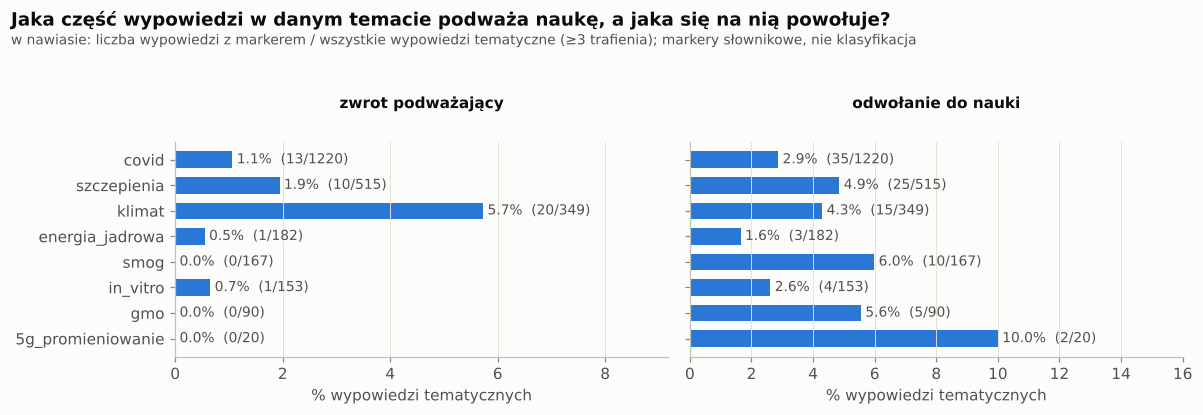

,wypowiedzi,nauka %,sceptycyzm %,nauka n,sceptycyzm n
covid,1220,2.87,1.07,35,13
szczepienia,515,4.85,1.94,25,10
klimat,349,4.30,5.73,15,20
energia_jadrowa,182,1.65,0.55,3,1
smog,167,5.99,0.00,10,0
in_vitro,153,2.61,0.65,4,1
gmo,90,5.56,0.00,5,0
5g_promieniowanie,20,10.00,0.00,2,0


In [23]:
# Markery wg tematu: w których tematach pojawia się język podważający?
mt = pd.DataFrame({
    "wypowiedzi": [m[f"{t}_tem"].sum() for t in kol],
    "nauka %": [(m.loc[m[f"{t}_tem"], "nauka"] > 0).mean() * 100 for t in kol],
    "sceptycyzm %": [(m.loc[m[f"{t}_tem"], "sceptycyzm"] > 0).mean() * 100 for t in kol],
}, index=kol)
mt["nauka n"] = [(m[f"{t}_tem"] & (m["nauka"] > 0)).sum() for t in kol]
mt["sceptycyzm n"] = [(m[f"{t}_tem"] & (m["sceptycyzm"] > 0)).sum() for t in kol]
mt.to_csv(PROC / "eda_markery_tematy.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
y = np.arange(len(mt))
for ax, col, title in [(axes[0], "sceptycyzm", "zwrot podważający"), (axes[1], "nauka", "odwołanie do nauki")]:
    ax.barh(y, mt[f"{col} %"], color=ACCENT, height=0.65)
    for yi, (v, k, n) in enumerate(zip(mt[f"{col} %"], mt[f"{col} n"], mt["wypowiedzi"])):
        ax.text(v, yi, f" {v:.1f}%  ({k}/{n})", va="center", fontsize=9, color=INK2)
    ax.set_title(title, fontsize=10, loc="center"); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, mt[f"{col} %"].max() * 1.6); ax.set_xlabel("% wypowiedzi tematycznych")
axes[0].set_yticks(y, mt.index); axes[0].invert_yaxis()
fig.suptitle("Jaka część wypowiedzi w danym temacie podważa naukę, a jaka się na nią powołuje?", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.9, "w nawiasie: liczba wypowiedzi z markerem / wszystkie wypowiedzi tematyczne (≥3 trafienia); markery słownikowe, nie klasyfikacja",
         fontsize=9, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.9))
save(fig, "11_markery_tematy"); plt.show()
mt

### Klimat w czasie: ile się mówi i ile się podważa
Kwartalnie, wspólna oś czasu. **Górny panel:** wypowiedzi wspominające klimat (≥1 trafienie) i wypowiedzi tematyczne (≥3).
**Dolny panel:** wypowiedzi wspominające klimat, które zawierają zwrot podważający („klimatyzm”, „ekoterroryzm”, „histeria klimatyczna”...),
z podziałem Konfederacja / pozostali. Liczymy tu wszystkie wzmianki, a nie tylko wypowiedzi tematyczne, bo podważanie często pada
mimochodem w debatach o rolnictwie czy energetyce.

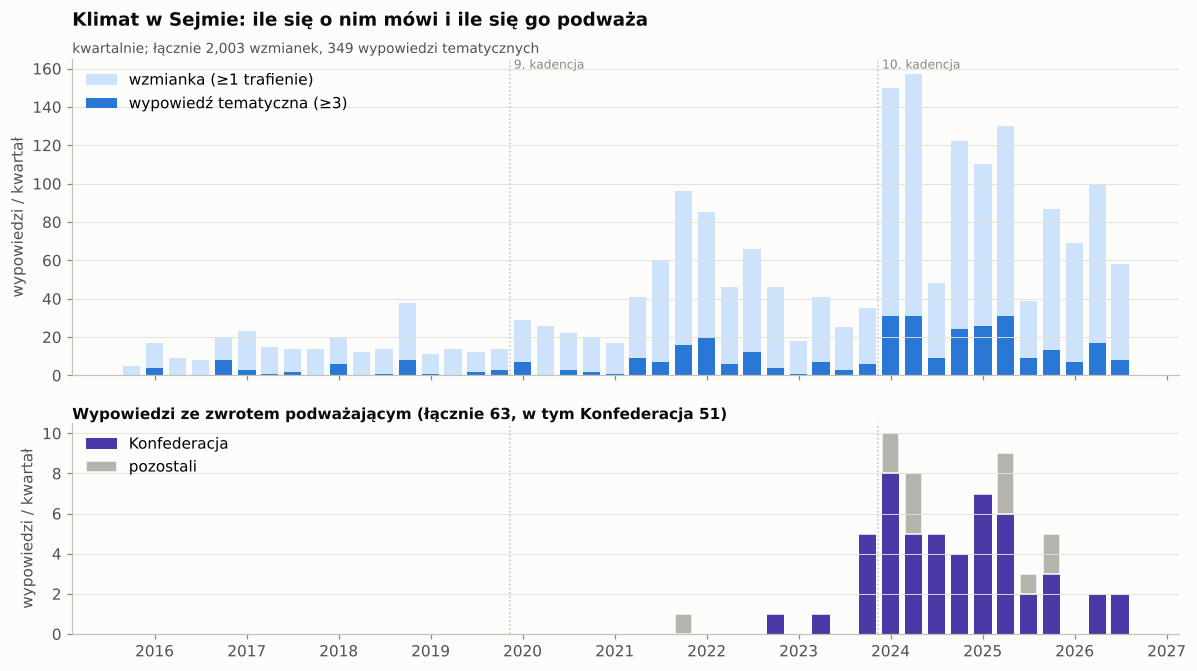

,wzmianki,tematyczne,podważające,w tym Konfederacja,% podważających (wśród wzmianek)
rok,,,,,
2015,5,0,0,0,0.00
2016,54,12,0,0,0.00
2017,66,6,0,0,0.00
2018,84,15,0,0,0.00
2019,51,6,0,0,0.00
2020,97,12,0,0,0.00
2021,214,33,1,0,0.50
2022,243,42,1,1,0.40
2023,119,17,6,6,5.00


In [24]:
OS_Q = pd.date_range(m["data"].min().to_period("Q").to_timestamp(), m["data"].max().to_period("Q").to_timestamp(), freq="QS")

def wykres_temat_w_czasie(wzm_mask, tem_mask, nazwa, tytul, plik):
    # Dwa panele na wspólnej osi czasu: ile się mówi o temacie i ile wypowiedzi zawiera zwrot podważający
    kl = m[wzm_mask].copy()
    kl["kwartal"] = kl["data"].dt.to_period("Q").dt.to_timestamp()
    wzm = kl.groupby("kwartal").size().reindex(OS_Q, fill_value=0)
    tem_q = kl[tem_mask[wzm_mask]].groupby("kwartal").size().reindex(OS_Q, fill_value=0)
    sc = kl[kl["sceptycyzm"] > 0]
    sc_konf = sc[sc["blok"].eq("Konfederacja")].groupby("kwartal").size().reindex(OS_Q, fill_value=0)
    sc_inni = sc[~sc["blok"].eq("Konfederacja")].groupby("kwartal").size().reindex(OS_Q, fill_value=0)
    pd.DataFrame({"wzmianki": wzm, "tematyczne": tem_q, "podwazajace_konfederacja": sc_konf,
                  "podwazajace_pozostali": sc_inni}).to_csv(PROC / f"eda_{nazwa}_kwartalnie.csv")

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
    w = 70
    a1.bar(OS_Q, wzm, width=w, color="#cde2fb", label="wzmianka (≥1 trafienie)")
    a1.bar(OS_Q, tem_q, width=w, color=ACCENT, label="wypowiedź tematyczna (≥3)")
    a1.set_ylabel("wypowiedzi / kwartał"); a1.legend(loc="upper left"); a1.grid(axis="x", visible=False)
    a1.set_title(tytul)
    subtitle(a1, f"kwartalnie; łącznie {int(wzm.sum()):,} wzmianek, {int(tem_q.sum()):,} wypowiedzi tematycznych")
    a2.bar(OS_Q, sc_konf, width=w, color=BLOK_KOLOR["Konfederacja"], label="Konfederacja")
    a2.bar(OS_Q, sc_inni, width=w, bottom=sc_konf, color=BLOK_KOLOR["Inne / niez."], label="pozostali", edgecolor=SURF, linewidth=1)
    a2.set_ylabel("wypowiedzi / kwartał"); a2.legend(loc="upper left"); a2.grid(axis="x", visible=False)
    a2.text(0, 1.02, f"Wypowiedzi ze zwrotem podważającym (łącznie {len(sc)}, w tym Konfederacja {int(sc_konf.sum())})",
            transform=a2.transAxes, fontsize=10, fontweight="bold", color=INK)
    a2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    for ax in (a1, a2):
        kadencje_tlo(ax, label=(ax is a1))
    a2.xaxis.set_major_locator(mdates.YearLocator()); a2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.tight_layout(h_pad=1.5)
    save(fig, plik); plt.show()

    roczne = pd.DataFrame({"wzmianki": kl.groupby("rok").size(), "tematyczne": kl[tem_mask[wzm_mask]].groupby("rok").size(),
                           "podważające": sc.groupby("rok").size(),
                           "w tym Konfederacja": sc[sc["blok"].eq("Konfederacja")].groupby("rok").size()}).fillna(0).astype(int)
    roczne["% podważających (wśród wzmianek)"] = (roczne["podważające"] / roczne["wzmianki"] * 100).round(1)
    return roczne

wykres_temat_w_czasie(m["klimat"] > 0, m["klimat_tem"], "klimat",
                      "Klimat w Sejmie: ile się o nim mówi i ile się go podważa", "12_klimat_w_czasie")

### Zdrowie (szczepienia + COVID-19) w czasie: ile się mówi i ile się podważa
Ten sam układ co dla klimatu. Łączymy dwa tematy medyczne z wyraźnym konsensusem naukowym: szczepienia i COVID-19
(wypowiedź liczy się raz, nawet jeśli dotyczy obu). Zwroty podważające to tu m.in. „eksperyment medyczny”, „segregacja sanitarna”,
„tzw. pandemia”, „plandemia”, „sanitaryzm”.

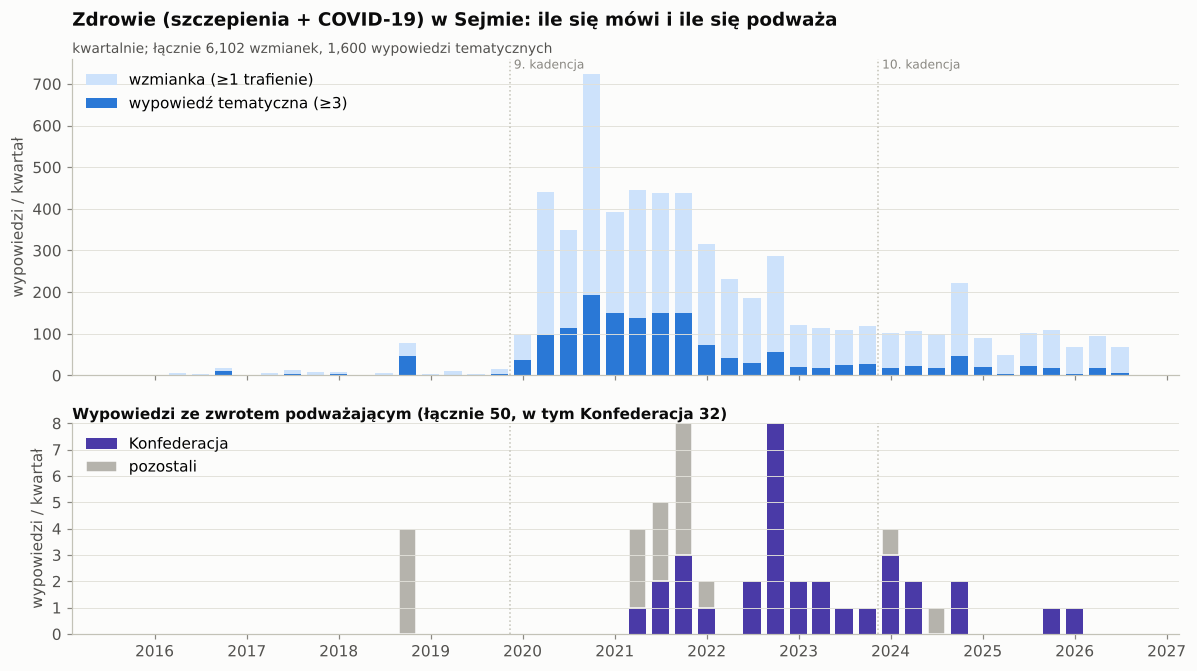

,wzmianki,tematyczne,podważające,w tym Konfederacja,% podważających (wśród wzmianek)
rok,,,,,
2015,2,0,0,0,0.00
2016,29,12,0,0,0.00
2017,29,7,0,0,0.00
2018,92,51,4,0,4.30
2019,33,6,0,0,0.00
2020,1609,442,0,0,0.00
2021,1714,589,17,6,1.00
2022,1020,201,12,11,1.20
2023,461,92,6,6,1.30


In [25]:
zdr_wzm = (m["szczepienia"] > 0) | (m["covid"] > 0)
zdr_tem = m["szczepienia_tem"] | m["covid_tem"]
wykres_temat_w_czasie(zdr_wzm, zdr_tem, "zdrowie",
                      "Zdrowie (szczepienia + COVID-19) w Sejmie: ile się mówi i ile się podważa", "13_zdrowie_w_czasie")

In [26]:
# Przykładowe wypowiedzi ze zwrotami podważającymi — materiał na ewentualne „sprzeczności” z konsensusem
display(Markdown(przyklady(m["dowolny_tem"] & (m["sceptycyzm"] > 0), T.SKEPTIC_RE, n=8, seed=7)))

- *Robert Winnicki (Konfederacja), 2022-01-13:* … chorobę. W ten sposób uniknęlibyśmy nadmiarowych zgonów. A procedować należy nad wnioskiem nad ustawą posłów Konfederacji i części posłów PiS-u Stop **segregacji sanitarnej**.
- *Agnieszka Pomaska (KO), 2023-06-15:* …e skandaliczne słowa o produkcji ludzi. Jan Duda, nazwisko nieprzypadkowe, samorządowiec PiS, w debacie samorządowej o in vitro mówił, że in vitro to **eksperyment medyczny**. Poseł Cymański, który dzisiaj jest posłem, zasiada bardzo regularnie w tej sali, mówił, że in vitro nie jest żadną radością. Więc chcę dzisiaj powie…
- *Witold Tumanowicz (Konfederacja), 2024-09-26:* …wimy, to zapłacimy 20 tys. euro za każdego nieprzyjętego. Polaków nie stać na to, aby utrzymywać imigrantów. Kolejny obszar, zielony ład i ta religia **klimatyzmu**. Wizja Europy bez samochodów spalinowych, bez emisji CO 2 . Ten sen ideologów klimatyzmu kosztuje nas miliardy, przez co staje się koszmarem dla zwyk…
- *Witold Tumanowicz (Konfederacja), 2025-11-07:* …zę wprowadzić do sąsiada, tylko to, żeby tę kozę wyprowadzić - i normalnie mieć zdrową energię, zdrową, stabilną energetykę, nieopartą na tej religii **klimatyzmu**. Dziękuję bardzo.
- *Michał Urbaniak (Konfederacja), 2022-11-04:* … jak powiedziałem, będzie tylko i wyłącznie na otarcie łez. Mam wrażenie, że rząd nie radzi sobie, przynajmniej częściowo z takim pseudoekologami i z **ekoterrorystami**, jak niektórzy mówią. Dzisiaj rozmawiamy na tej sali właśnie o wsparciu polskiej branży hodowli trzody chlewnej. Jakie plakaty dzisiaj można było zna…
- *Grzegorz Lorek (PiS), 2024-04-26:* …olsce w roku 2022 54 mln t, zaś w Niemczech 161 mln t. Zielony ład miał być rewolucją społeczną i gospodarczą, a tak naprawdę jest kolejnym przejawem **ekoterroryzmu**, który niestety dotyka każdego obszaru życia codziennego. W ostatnich dniach obserwujemy, że niewątpliwie polski, ale również europejski przemysł pad…
- *Roman Fritz (Konfederacja), 2023-12-20:* …ię stało? Praprzyczyną oczywiście jest członkostwo w Unii Europejskiej i poddawanie się jej dyktatowi, tym absurdom, temu obłędowi, tej pseudoreligii **klimatyzmu**, marksizmu, zielonym ładom, jakimś czarodziejskim sztuczkom, które każą nam wierzyć w to, że fotowoltaika, wiatraczki zapewnią nam dość energii. Nie,…
- *Jacek Wilk (niez.), 2018-10-03:* …lski: żaden urząd ani organ w Polsce nie ma badań potwierdzających skuteczność i bezpieczeństwo szczepień. Co za tym idzie, szanowni państwo, jest to **eksperyment medyczny**, a skoro tak, to zgodnie z polską konstytucją nikt nie może być poddawany eksperymentom medycznym lub naukowym bez jego zgody. Wobec tego pytanie, cz…

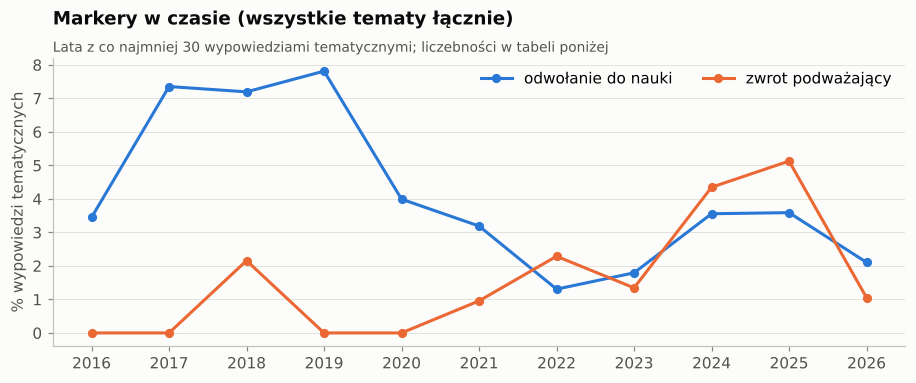

rok,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
n,87.00,68.00,139.00,64.00,476.00,627.00,306.00,223.00,253.00,195.00,95.00
nauka,3.40,7.40,7.20,7.80,4.00,3.20,1.30,1.80,3.60,3.60,2.10
sceptycyzm,0.00,0.00,2.20,0.00,0.00,1.00,2.30,1.30,4.30,5.10,1.10


In [27]:
# Czy markery zmieniają się w czasie? Udział wypowiedzi tematycznych z markerem, wg roku
tt = m[m["dowolny_tem"]]
rok = tt.groupby("rok").agg(n=("wypowiedz_id", "size"),
                            nauka=("nauka", lambda x: (x > 0).mean() * 100),
                            sceptycyzm=("sceptycyzm", lambda x: (x > 0).mean() * 100))
rok = rok[rok["n"] >= 30]  # pomijamy lata z bardzo małą liczbą wypowiedzi (np. końcówka 2015)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(rok.index, rok["nauka"], color=ACCENT, marker="o", ms=5, label="odwołanie do nauki")
ax.plot(rok.index, rok["sceptycyzm"], color="#eb6834", marker="o", ms=5, label="zwrot podważający")
ax.set_xticks(rok.index); ax.grid(axis="x", visible=False)
ax.set_ylabel("% wypowiedzi tematycznych"); ax.legend(loc="upper right", ncol=2)
ax.set_title("Markery w czasie (wszystkie tematy łącznie)")
subtitle(ax, "Lata z co najmniej 30 wypowiedziami tematycznymi; liczebności w tabeli poniżej")
save(fig, "10_markery_czas"); plt.show()
rok.T.round(1)

## 8. Komisje sejmowe: Komisja Zdrowia (ZDR) i Komisja Ochrony Środowiska (OSZ)
Posiedzenia plenarne to tylko część pracy Sejmu. Szczegółowe spory merytoryczne toczą się w **komisjach**, gdzie oprócz posłów
głos zabierają przedstawiciele rządu, eksperci, organizacje i — przy wysłuchaniach publicznych — obywatele.
Pobraliśmy pełne zapisy dwóch komisji kluczowych dla obu osi projektu (skrypt `src/fetch_komisje.py`):
* **ZDR — Komisja Zdrowia** (szczepienia, COVID-19),
* **OSZ — Komisja Ochrony Środowiska, Zasobów Naturalnych i Leśnictwa** (klimat, smog).

API zwraca jeden dokument na posiedzenie; wypowiedzi wydzielamy po etykietach mówców („Poseł Jan Kowalski (PiS):”).
Stosujemy te same słowniki, progi i filtr (bez prowadzącego, ≥ 40 słów) co dla posiedzeń plenarnych.

In [28]:
KOM_NAZWA = {"ZDR": "Komisja Zdrowia", "OSZ": "Komisja Ochrony Środowiska"}
k = pd.concat([pd.read_parquet(p) for t in TERMS
               if (p := ROOT / f"data/interim/komisje_wypowiedzi_term{t}.parquet").exists()], ignore_index=True)
k = k[k["komisja"].isin(KOM_NAZWA)].copy()
k["data"] = pd.to_datetime(k["data"])
k["rok"] = k["data"].dt.year
# wtrącenia z sali w nawiasach usuwamy tak jak w stenogramach plenarnych
k["tekst"] = k["tekst"].fillna("").map(lambda t: re.sub(r"[ \t]+", " ", re.sub(r"\([^()]*\)", " ", t)).strip())
k["liczba_slow"] = k["tekst"].str.split().str.len().fillna(0).astype(int)
k["blok"] = k["klub"].map(KLUB_BLOK)
k.loc[k["member_id"].gt(0) & k["blok"].isna(), "blok"] = "Inne / niez."

przeg_k = k.groupby(["komisja", "kadencja"]).agg(
    posiedzenia=("posiedzenie_nr", "nunique"), wypowiedzi=("wypowiedz_id", "size"), slowa=("liczba_slow", "sum"),
    z_pdf=("zrodlo", lambda x: (x == "pdf").mean() * 100))
role_k = pd.crosstab([k["komisja"], k["kadencja"]], k["rola"], values=k["liczba_slow"], aggfunc="sum", normalize="index") * 100
przeg_k = przeg_k.join(role_k.add_prefix("% słów: "))
print(f"{len(k):,} wypowiedzi, {k['liczba_slow'].sum():,} słów z {k.groupby(['komisja', 'kadencja', 'posiedzenie_nr']).ngroups:,} posiedzeń")
przeg_k.round(1)

119,464 wypowiedzi, 9,416,396 słów z 1,158 posiedzeń


posiedzenia  wypowiedzi    slowa  z_pdf  % słów: inni  \
komisja kadencja                                                          
OSZ     8                 201       18544  1455978   0.00         30.30   
        9                 185       14490  1418686   0.00         29.10   
        10                136       13797  1499250   0.00         30.50   
ZDR     8                 197       19726  1367137   0.00         21.40   
        9                 276       38750  2405074   0.00         22.30   
        10                163       14157  1270271   0.00         26.30   

                  % słów: poseł  % słów: prowadzący  % słów: rząd  
komisja kadencja                                                   
OSZ     8                 29.60               22.00         18.00  
        9                 33.20               16.40         21.20  
        10                34.70               14.00         20.80  
ZDR     8                 32.50               23.00         23.00  
        9                 35.80               23.80         18.10  
        10                38.00               15.90         19.70

**Kto mówi w komisjach?** W komisjach znacznie większą część słów wypowiadają osoby spoza Sejmu (rola „inni”: eksperci, NFZ,
organizacje, goście wysłuchań) i przedstawiciele rządu. Dla projektu to ważne: część wypowiedzi sprzecznych z konsensusem
może pochodzić od **gości**, a nie posłów — trzeba zdecydować, czy wchodzą do analizy.

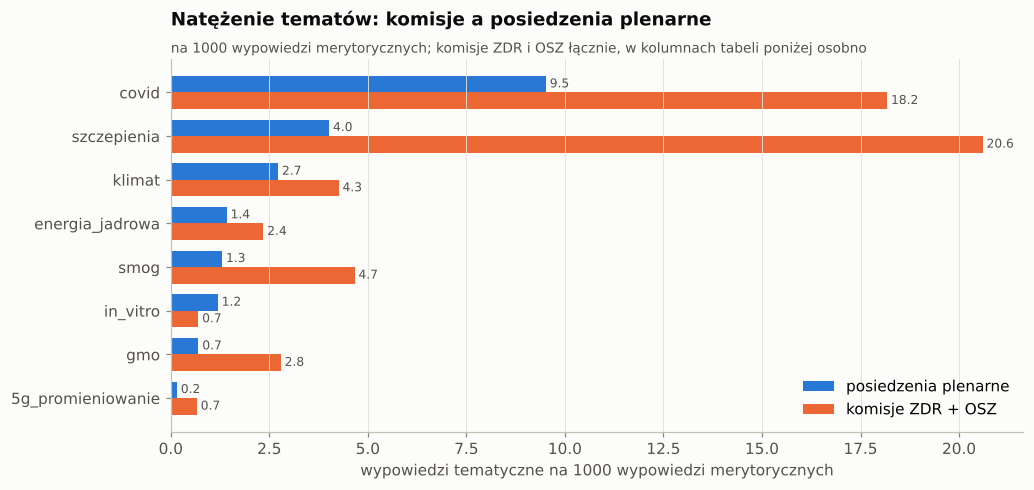

,plenarne: tematyczne,komisje: tematyczne,plenarne ‰,komisje ‰,ZDR ‰,OSZ ‰
covid,1220,495,9.50,18.20,33.60,1.60
szczepienia,515,561,4.00,20.60,39.60,0.20
klimat,349,116,2.70,4.30,0.00,8.80
energia_jadrowa,182,64,1.40,2.40,0.30,4.60
smog,167,127,1.30,4.70,1.90,7.60
in_vitro,153,19,1.20,0.70,1.30,0.00
gmo,90,76,0.70,2.80,0.00,5.80
5g_promieniowanie,20,18,0.20,0.70,0.00,1.40


In [29]:
km = k[(k["rola"] != "prowadzący") & (k["liczba_slow"] >= MIN_SLOW)].copy()
km = km.join(T.flag_topics(km["tekst"]))
for t in TEMATY:
    km[f"{t}_tem"] = km[t] >= PROG
km["zdrowie_tem"] = km["szczepienia_tem"] | km["covid_tem"]
km["zdrowie_wzm"] = (km["szczepienia"] > 0) | (km["covid"] > 0)
m["zdrowie_tem"] = m["szczepienia_tem"] | m["covid_tem"]

por = pd.DataFrame({
    "plenarne: tematyczne": [m[f"{t}_tem"].sum() for t in kol],
    "komisje: tematyczne": [km[f"{t}_tem"].sum() for t in kol],
    "plenarne ‰": [m[f"{t}_tem"].mean() * 1000 for t in kol],
    "komisje ‰": [km[f"{t}_tem"].mean() * 1000 for t in kol],
}, index=kol)
por["ZDR ‰"] = [km.loc[km["komisja"] == "ZDR", f"{t}_tem"].mean() * 1000 for t in kol]
por["OSZ ‰"] = [km.loc[km["komisja"] == "OSZ", f"{t}_tem"].mean() * 1000 for t in kol]
por.to_csv(PROC / "eda_komisje_vs_plenarne.csv")

fig, ax = plt.subplots(figsize=(10, 4.4))
y = np.arange(len(kol)); h = 0.38
ax.barh(y - h / 2, por["plenarne ‰"], height=h, color=ACCENT, label="posiedzenia plenarne")
ax.barh(y + h / 2, por["komisje ‰"], height=h, color="#eb6834", label="komisje ZDR + OSZ")
for yi, (a, b) in enumerate(zip(por["plenarne ‰"], por["komisje ‰"])):
    ax.text(a, yi - h / 2, f" {a:.1f}", va="center", fontsize=8, color=INK2)
    ax.text(b, yi + h / 2, f" {b:.1f}", va="center", fontsize=8, color=INK2)
ax.set_yticks(y, kol); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("wypowiedzi tematyczne na 1000 wypowiedzi merytorycznych")
ax.legend(loc="lower right")
ax.set_title("Natężenie tematów: komisje a posiedzenia plenarne")
subtitle(ax, "na 1000 wypowiedzi merytorycznych; komisje ZDR i OSZ łącznie, w kolumnach tabeli poniżej osobno")
save(fig, "14_komisje_vs_plenarne"); plt.show()
por.round(1)

### Komisje w czasie
Liczba wypowiedzi tematycznych rocznie: zdrowie (szczepienia + COVID) i klimat — na posiedzeniach plenarnych i w komisjach.
Komisje dają **dodatkowy** materiał: dla zdrowia ok. 60% tego, co sala plenarna, dla klimatu ok. 1/3. Klimat w komisjach jest
zaniżony, bo polityka klimatyczna trafia głównie do Komisji Energii, Klimatu i Aktywów Państwowych (ESK), której jeszcze nie pobraliśmy.

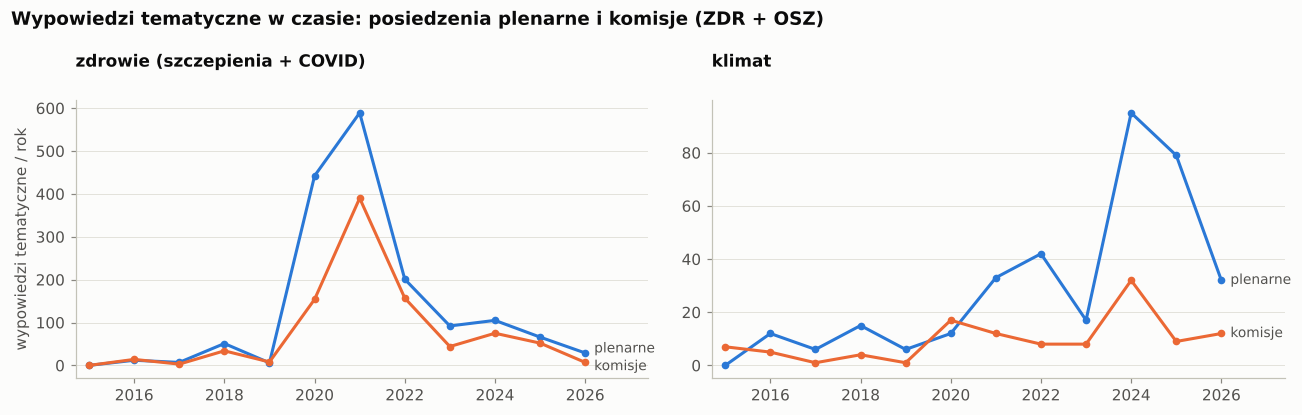

In [30]:
lata = sorted(set(m["rok"]) | set(km["rok"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, (kol_t, nazwa) in zip(axes, [("zdrowie_tem", "zdrowie (szczepienia + COVID)"), ("klimat_tem", "klimat")]):
    pl = m[m[kol_t]].groupby("rok").size().reindex(lata, fill_value=0)
    ko = km[km[kol_t]].groupby("rok").size().reindex(lata, fill_value=0)
    ax.plot(lata, pl, color=ACCENT, marker="o", ms=4)
    ax.plot(lata, ko, color="#eb6834", marker="o", ms=4)
    # etykiety na końcu linii; gdy końce są blisko siebie, rozsuwamy je w pionie
    y_pl, y_ko = pl.iloc[-1], ko.iloc[-1]
    odstep = 0.07 * max(pl.max(), ko.max())
    if abs(y_pl - y_ko) < odstep:
        sr = (y_pl + y_ko) / 2
        y_pl, y_ko = (sr + odstep / 2, sr - odstep / 2) if y_pl >= y_ko else (sr - odstep / 2, sr + odstep / 2)
    ax.text(lata[-1] + 0.2, y_pl, "plenarne", color=INK2, fontsize=9, va="center")
    ax.text(lata[-1] + 0.2, y_ko, "komisje", color=INK2, fontsize=9, va="center")
    ax.set_title(nazwa, fontsize=11, loc="left"); ax.grid(axis="x", visible=False)
    ax.set_xlim(lata[0] - 0.3, lata[-1] + 1.4)
axes[0].set_ylabel("wypowiedzi tematyczne / rok")
fig.suptitle("Wypowiedzi tematyczne w czasie: posiedzenia plenarne i komisje (ZDR + OSZ)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "15_komisje_w_czasie"); plt.show()

### Kto mówi o tematach naukowych w komisjach?
Udział ról wśród wypowiedzi tematycznych — w komisjach dużą część stanowią rząd i goście (eksperci, organizacje, obywatele).

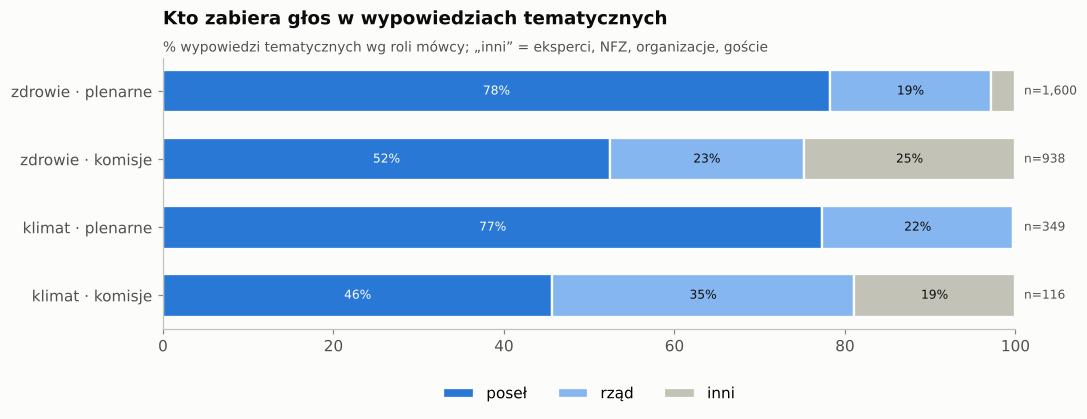

In [31]:
ROLE = ["poseł", "rząd", "inni"]
ROLE_KOLOR = {"poseł": ACCENT, "rząd": "#86b6ef", "inni": "#c3c2b7"}
wiersze = {}
for nazwa, kol_t in [("zdrowie", "zdrowie_tem"), ("klimat", "klimat_tem")]:
    wiersze[f"{nazwa} · plenarne"] = m.loc[m[kol_t], "rola"].value_counts(normalize=True)
    wiersze[f"{nazwa} · komisje"] = km.loc[km[kol_t], "rola"].value_counts(normalize=True)
rt = pd.DataFrame(wiersze).T.reindex(columns=ROLE).fillna(0) * 100
n_rt = {f"{n} · {src}": (d[d[c]]).shape[0] for n, c in [("zdrowie", "zdrowie_tem"), ("klimat", "klimat_tem")]
        for src, d in [("plenarne", m), ("komisje", km)]}

fig, ax = plt.subplots(figsize=(10, 3.2))
left = np.zeros(len(rt))
for r in ROLE:
    ax.barh(range(len(rt)), rt[r], left=left, color=ROLE_KOLOR[r], height=0.62, edgecolor=SURF, linewidth=1.5, label=r)
    for i, (l, w) in enumerate(zip(left, rt[r])):
        if w >= 7:
            ax.text(l + w / 2, i, f"{w:.0f}%", ha="center", va="center", fontsize=8, color="white" if r == "poseł" else INK)
    left += rt[r].values
for i, idx in enumerate(rt.index):
    ax.text(101, i, f"n={n_rt[idx]:,}", va="center", fontsize=8, color=INK2)
ax.set_yticks(range(len(rt)), rt.index); ax.invert_yaxis(); ax.set_xlim(0, 100); ax.grid(False)
ax.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.32))
ax.set_title("Kto zabiera głos w wypowiedziach tematycznych")
subtitle(ax, "% wypowiedzi tematycznych wg roli mówcy; „inni” = eksperci, NFZ, organizacje, goście")
save(fig, "16_komisje_role"); plt.show()

### Markery sceptycyzmu w komisjach
Odsetek wypowiedzi tematycznych (zdrowie lub klimat) ze zwrotem podważającym — wg roli mówcy i, dla posłów, wg bloku.

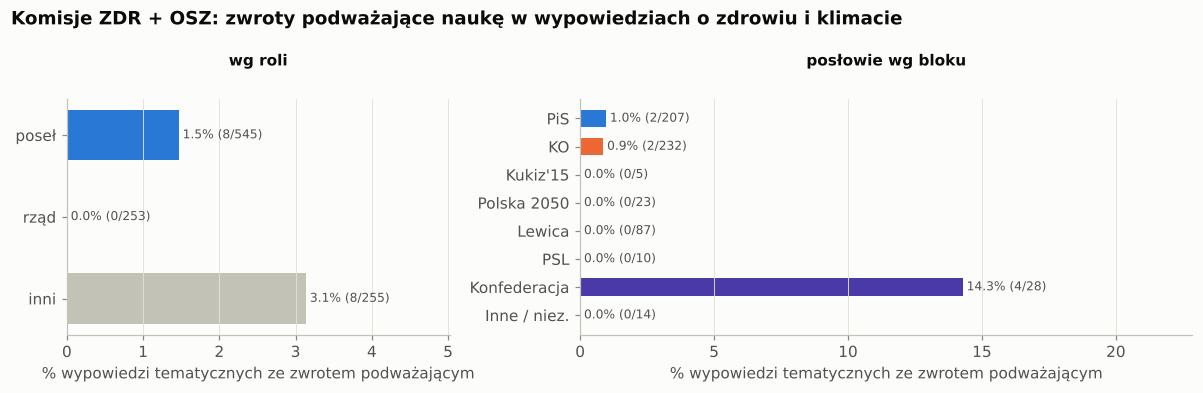

,wypowiedzi,sceptyczne,%
rola,,,
inni,255,8,3.10
poseł,545,8,1.50
rząd,253,0,0.00


,wypowiedzi,sceptyczne,%
blok,,,
PiS,207,2,1.00
KO,232,2,0.90
Kukiz'15,5,0,0.00
Polska 2050,23,0,0.00
Lewica,87,0,0.00
PSL,10,0,0.00
Konfederacja,28,4,14.30
Inne / niez.,14,0,0.00


In [32]:
kt = km[km["zdrowie_tem"] | km["klimat_tem"]]
mr = kt.groupby("rola").agg(wypowiedzi=("wypowiedz_id", "size"), sceptyczne=("sceptycyzm", lambda x: (x > 0).sum()))
mr["%"] = mr["sceptyczne"] / mr["wypowiedzi"] * 100
mb = kt[kt["member_id"] > 0].groupby("blok").agg(wypowiedzi=("wypowiedz_id", "size"), sceptyczne=("sceptycyzm", lambda x: (x > 0).sum()))
mb["%"] = mb["sceptyczne"] / mb["wypowiedzi"] * 100
mb = mb.reindex([b for b in BLOKI if b in mb.index])
mr.to_csv(PROC / "eda_komisje_markery_role.csv"); mb.to_csv(PROC / "eda_komisje_markery_bloki.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1, 1.6]})
for ax, tab, kolory, tytul in [(axes[0], mr.reindex([r for r in ROLE if r in mr.index]), None, "wg roli"),
                               (axes[1], mb, "blok", "posłowie wg bloku")]:
    yy = np.arange(len(tab))
    c = [BLOK_KOLOR[b] for b in tab.index] if kolory else [ROLE_KOLOR[r] for r in tab.index]
    ax.barh(yy, tab["%"], color=c, height=0.62)
    for yi, (v, s_, n_) in enumerate(zip(tab["%"], tab["sceptyczne"], tab["wypowiedzi"])):
        ax.text(v, yi, f" {v:.1f}% ({s_}/{n_})", va="center", fontsize=8, color=INK2)
    ax.set_yticks(yy, tab.index); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, max(tab["%"].max() * 1.6, 1)); ax.set_title(tytul, fontsize=10, loc="center")
    ax.set_xlabel("% wypowiedzi tematycznych ze zwrotem podważającym")
fig.suptitle("Komisje ZDR + OSZ: zwroty podważające naukę w wypowiedziach o zdrowiu i klimacie", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "17_komisje_markery"); plt.show()
display(mr.round(1)); display(mb.round(1))

In [33]:
# Przykłady z komisji — kto i jak podważa (losowo, do 8)
def przyklady_k(maska, rx, n=8, seed=3):
    s = km[maska].sample(min(n, int(maska.sum())), random_state=seed).sort_values("data")
    out = []
    for _, r in s.iterrows():
        frag = kwic(r["tekst"], rx).replace("\n", " ")
        kto = r["klub"] if isinstance(r["klub"], str) and r["rola"] == "poseł" else r["rola"]
        out.append(f"- *{r['etykieta']} [{kto}], {r['komisja']}, {r['data']:%Y-%m-%d}:* {frag}")
    return "\n".join(out)

display(Markdown(przyklady_k((km["zdrowie_tem"] | km["klimat_tem"]) & (km["sceptycyzm"] > 0), T.SKEPTIC_RE)))

- *Poseł Jerzy Hardie-Douglas (KO) [KO], ZDR, 2021-06-23:* …każdą bzdurą, która jest na portalu wypisywana, a są tam tego typu informacje jak plany depopulacji planety, spisek firm farmaceutycznych, nieludzkie **eksperymenty na ludziach**, które są robione przy produkcji szczepionek, porównuje się paszporty covidowe do kenkarty wydawanej przez III Rzeszę itd. – pod każdym z tych idioty…
- *Poseł Czesław Hoc (PiS) [PiS], ZDR, 2021-12-16:* …. Proszę państwa, projekt jest bardzo ostrożny, bardzo wyważony, powiedziałbym nawet koncyliacyjny, który do niczego nie zmusza i nie powoduje żadnej **segregacji sanitarnej**. Przypomnę i podkreślę główne zarysy naszego projektu poselskiego, który opiera się na podstawowych trzech komponentach. Pierwszy komponent jest taki…
- *Poseł Katarzyna Sójka (PiS) [PiS], ZDR, 2021-12-16:* …yć może tak będzie... Jestem więc przekonana, że panowie nie do końca macie pojęcie o tym, na czym polega epidemiologia i że tak naprawdę to nie jest **sanitaryzm** – jak to wy określacie – tylko to jest po prostu różnicowanie na osoby, które mają większy potencjał do tego, żeby się zarazić i kogoś zarazić, i na …
- *Pani Monika Katarzyna Bereźnicka [inni], ZDR, 2022-01-05:* …ypowiadać tutaj głównie jako mama, ponieważ chciałabym zapytać, dlaczego minister zdrowia i minister Czarnek pozwalają, aby w szkołach była stosowana **segregacja sanitarna**, dzielenie dzieci na lepsze i gorsze? Moje dziecko nie jest zaszczepione preparatem, który jest w dalszym ciągu w fazie badań klinicznych, który jest…
- *Pani Kalina Bednarczyk [inni], ZDR, 2022-01-05:* …atahy Głosu Obywatelskiego. Kiedy prześledzimy stanowiska ekspertów, których opiniami podpiera się rząd w przypadku planowania polityki zdrowotnej do **rzekomej pandemii** COVID-19, zauważymy rozbieżność w przekazie informacji nawet wśród tych samych osób wypowiadających się w pewnych odstępach czasu, nazwijmy go, pande…
- *Pan Piotr Witczak [inni], ZDR, 2022-01-05:* …nologia. Zawodowo zajmowałem się oceną technologii medycznych. Reprezentuję również ruch Polska Jest Jedna i Fundację Ordo Medicus. Szanowni państwo, **segregacja sanitarna**, opierająca się na programach szczepień przeciw COVID-19, nie redukuje transmisji wirusa. W krajach europejskich im większy odsetek zaszczepionej pop…
- *Poseł Krzysztof Tuduj (Konfederacja) [Konfederacja], ZDR, 2022-10-27:* …iarką, panią żołnierz w służbie czynnej, która stara się o dziecko i pytała mnie o to, że nie ma badań dotyczących wpływu na płodność tego preparatu, **tak zwanej szczepionki**, a jest na niej wymuszane, żeby była zaszczepiona. Podam przykład innej też bieżącej sytuacji. Mam wiedzę, że w jednej z jednostek spadochroniarze ni…
- *Poseł Włodzimierz Skalik (Konfederacja) [Konfederacja], OSZ, 2024-03-07:* …ństwo, pani przewodnicząca. Zwracam się tutaj z propozycją do prezydium Komisji. Jest bardzo wielu ekspertów w kraju i za granicą, którzy kwestionują **klimatyzm**, tę nową „zieloną komunę”, więc chciałbym zachęcić prezydium do zorganizowania otwartej debaty na terenie Sejmu z zaproszeniem ekspertów, którzy kryt…

## 9. Wnioski i rekomendacja
*(liczby wg danych pobranych 6.10.2026; kadencje VIII–X: posiedzenia plenarne 130,5 tys. wypowiedzi, ~42 mln słów po czyszczeniu; komisje ZDR i OSZ ~119 tys. wypowiedzi)*

### Tematy — ile materiału?
| temat | wypowiedzi tematyczne | wzmianki | ocena |
|---|---:|---:|---|
| COVID-19 | ~1 220 | ~5 500 | dużo materiału, ale skupione w latach 2020–2022 |
| szczepienia | ~515 | ~1 200 | wyraźny konsensus naukowy; pik 2021 (Narodowy Program Szczepień), mniejszy X–XI 2018 (debata o obowiązku szczepień) |
| klimat | ~350 | ~2 000 | jedyny temat **rosnący** w X kadencji; dużo wzmianek przy okazji rolnictwa i energetyki |
| energia jądrowa | ~180 | ~860 | debaty skupione wokół kilku ustaw (34% w 3 dniach) |
| smog | ~170 | ~800 | głównie VIII kadencja, potem temat znika |
| in vitro | ~150 | ~620 | **60% w 3 dniach** (debata o refundacji, XI 2023); bardziej spór etyczny niż naukowy |
| GMO, 5G | 90 / 20 | 250 / 100 | za mało na osobną oś; 5G to głównie aukcja częstotliwości |

### Czas
* Liczba wypowiedzi na te tematy **zależy od czasu, ale nie liniowo — jest napędzana wydarzeniami** (pandemia, konkretne ustawy, protesty rolników).
  Nie ma jednego trendu „coraz więcej nauki w Sejmie”.
* COVID/szczepienia: gwałtowny wzrost w 2020–2021 i wygaszanie do 2023.
* Klimat: stały, niski poziom w VIII–IX kadencji i **wyraźny wzrost w X kadencji** (2024–2025: Zielony Ład, protesty rolników, ETS2) —
  ale dyskusja dotyczy głównie *kosztów polityki klimatycznej*, a rzadziej samej nauki o klimacie.

### Partie
* **Konfederacja** wyróżnia się najbardziej: najwyższe natężenie klimatu (~10‰, ok. 4× średnia), razem z Lewicą najwyższe natężenie COVID (~17‰),
  a w jej wypowiedziach tematycznych **~13% (30 z 228) zawiera zwroty podważające** naukę lub ekspertów („eksperyment medyczny”, „religia klimatyzmu”,
  „ekoterroryści”) wobec ≤1,2% w pozostałych dużych klubach. Liczby bezwzględne są małe — to sygnał do sprawdzenia, nie wynik.
* **Lewica** dużo mówi o COVID i szczepieniach, ale *po stronie* konsensusu (dostęp do szczepień, personel medyczny).
* **KO** dominuje w in vitro i smogu; **PiS i KO** jako największe kluby dają najwięcej materiału w liczbach bezwzględnych.
* Odwołania wprost do nauki są **rzadkie** (2–6% wypowiedzi tematycznych) — sam filtr „nauka” wyłowi mało; sprzeczność z konsensusem
  trzeba będzie wykrywać po treści twierdzeń, nie po słowach „naukowcy/badania”.

### Rekomendacja kierunku
1. **Szczepienia + COVID** (~1 700 wypowiedzi tematycznych, IX kadencja): najjaśniejszy konsensus naukowy, wyraźny kontrast między partiami,
   gotowa taksonomia twierdzeń antyszczepionkowych (Kata 2012). Minus: materiał ograniczony do jednego okresu.
2. **Klimat (+ energetyka)** (~530 wypowiedzi tematycznych, ~2 900 wzmianek): rosnący trend, obecny we wszystkich kadencjach, gotowa taksonomia
   CARDS (Coan i in. 2021). Minus: trzeba oddzielić krytykę *polityki* klimatycznej (legalny spór polityczny) od podważania *nauki* o klimacie.
3. Smog, in vitro, GMO, 5G — jako materiał pomocniczy, nie oś projektu.

**Najmocniejszy wariant:** dwa tematy (zdrowie: szczepienia/COVID oraz klimat) — dają porównanie „który konsensus jest kwestionowany, przez kogo i kiedy”.

### Komisje sejmowe (ZDR, OSZ)
* 1 158 posiedzeń, ~119 tys. wypowiedzi, ~9,4 mln słów (VIII–X kadencja). Zapisy dobrze się parsują (99,7% etykiet posłów rozpoznanych).
* Materiał **uzupełnia** salę plenarną: zdrowie ~940 wypowiedzi tematycznych (60% wolumenu plenarnego), klimat ~120 (1/3 —
  klimat leży głównie w komisji ESK, do pobrania).
* W komisjach **co czwarta wypowiedź tematyczna o zdrowiu pochodzi spoza Sejmu** (eksperci, NFZ, organizacje, obywatele).
  Zwroty podważające są tam częstsze u gości (3,1%) niż u posłów (1,5%) — np. wysłuchanie w Komisji Zdrowia 5.01.2022
  („segregacja sanitarna”, „rzekoma pandemia”). Rząd: 0%.
* Wśród posłów wzorzec jak na sali plenarnej: Konfederacja ~14% (4/28), PiS i KO ~1% — przy czym trafienia PiS/KO to głównie polemika
  („to nie jest sanitaryzm”, „projekt nie powoduje segregacji sanitarnej”), a nie podważanie.
* Wniosek: komisje warto włączyć, ale z jawną decyzją, czy analizujemy tylko posłów, czy także gości wysłuchań publicznych.

### Ograniczenia i następne kroki
* Słowniki to filtr o nieznanej precyzji/czułości → ręcznie ocenić ~100 losowych trafień na temat (`data/gold`), dopracować słowniki,
  rozważyć lematyzację (Stanza / Morfeusz2).
* Porównać trafienia z etykietami tematów CAP z korpusu ParlaMint/ParlaCAP (VIII–IX kadencja) jako niezależną walidację.
* Ustalić schemat anotacji zgodności z konsensusem (CARDS dla klimatu, Kata dla szczepień) i dopiero potem klasyfikację automatyczną (np. LLM).